# Warehouse Operational Efficiency — Performance Analysis
### SupplyFlow FMCG Solutions | Data Science Capstone Project

| | |
|---|---|
| **Student** | Deepesh Kumar Gautam |
| **USN** | 233VBBR00561 |
| **Elective** | Data Science |
| **Project** | Analyzing Warehouse Operational Efficiency |

---
**Business Goal:** Identify key operational factors driving warehouse throughput and build a predictive model to support resource allocation and performance improvement decisions across the FMCG supply chain.

**Target Variable:** `product_wg_ton` — total product weight shipped per warehouse (proxy for operational throughput)

**ML Task:** Regression — predict continuous shipment output and surface operational drivers.

## 0. Setup & Library Imports
*All libraries for data processing, visualisation, and machine learning.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Initial Overview
*First inspection of shape, types, and content.*

In [2]:
df = pd.read_excel('/kaggle/input/datasets/dvipgk/supplyflow-fmcg-solutions-xlsx/SupplyFlow FMCG Solutions.xlsx')

print(f"Dataset Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names & Data Types:")
print(df.dtypes.to_string())

Dataset Shape  : 25,000 rows × 24 columns

Column Names & Data Types:
Ware_house_ID                    object
WH_Manager_ID                    object
Location_type                    object
WH_capacity_size                 object
zone                             object
WH_regional_zone                 object
num_refill_req_l3m                int64
transport_issue_l1y               int64
Competitor_in_mkt                 int64
retail_shop_num                   int64
wh_owner_type                    object
distributor_num                   int64
flood_impacted                    int64
flood_proof                       int64
electric_supply                   int64
dist_from_hub                     int64
workers_num                     float64
wh_est_year                     float64
storage_issue_reported_l3m        int64
temp_reg_mach                     int64
approved_wh_govt_certificate     object
wh_breakdown_l3m                  int64
govt_check_l3m                    int64
product_wg

In [3]:
df.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
num_refill_req_l3m,25000.0,4.09,2.61,0.0,2.0,4.0,6.0,8.0
transport_issue_l1y,25000.0,0.77,1.20,0.0,0.0,0.0,1.0,5.0
Competitor_in_mkt,25000.0,3.10,1.14,0.0,2.0,3.0,4.0,12.0
retail_shop_num,25000.0,4985.71,1052.83,1821.0,4313.0,4859.0,5500.0,11008.0
distributor_num,25000.0,42.42,16.06,15.0,29.0,42.0,56.0,70.0
flood_impacted,25000.0,0.10,0.30,0.0,0.0,0.0,0.0,1.0
flood_proof,25000.0,0.05,0.23,0.0,0.0,0.0,0.0,1.0
electric_supply,25000.0,0.66,0.47,0.0,0.0,1.0,1.0,1.0
dist_from_hub,25000.0,163.54,62.72,55.0,109.0,164.0,218.0,271.0
workers_num,24010.0,28.94,7.87,10.0,24.0,28.0,33.0,98.0


## 2. Data Quality Assessment
*Dtype verification, missing values, and duplicate check before any processing.*

In [5]:
dtype_check = pd.DataFrame({
    'Column'       : df.columns,
    'Stored As'    : df.dtypes.values,
    'Null Count'   : df.isnull().sum().values,
    'Null %'       : (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique Values': df.nunique().values
}).reset_index(drop=True)

print("=== Data Type & Quality Report ===")
print(dtype_check.to_string(index=False))
print(f"\nDuplicate Rows : {df.duplicated().sum()}")
print("\nNote: workers_num / wh_est_year stored as float64 due to missing values — correct, no dtype correction needed.")

=== Data Type & Quality Report ===
                      Column Stored As  Null Count  Null %  Unique Values
               Ware_house_ID    object           0    0.00          25000
               WH_Manager_ID    object           0    0.00          25000
               Location_type    object           0    0.00              2
            WH_capacity_size    object           0    0.00              3
                        zone    object           0    0.00              4
            WH_regional_zone    object           0    0.00              6
          num_refill_req_l3m     int64           0    0.00              9
         transport_issue_l1y     int64           0    0.00              6
           Competitor_in_mkt     int64           0    0.00             12
             retail_shop_num     int64           0    0.00           4906
               wh_owner_type    object           0    0.00              2
             distributor_num     int64           0    0.00             56
   

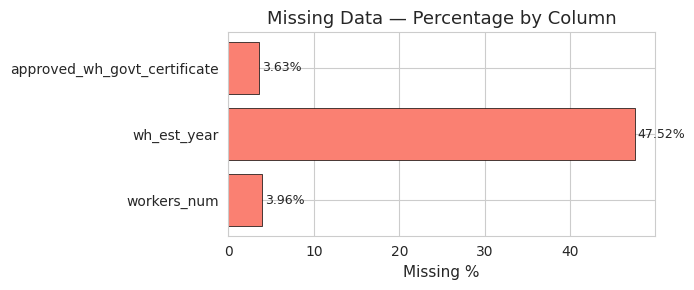

In [6]:
missing_only = dtype_check[dtype_check['Null Count'] > 0][['Column','Null %']]

plt.figure(figsize=(7, 3))
plt.barh(missing_only['Column'], missing_only['Null %'],
         color='salmon', edgecolor='black', linewidth=0.5)
plt.title('Missing Data — Percentage by Column')
plt.xlabel('Missing %')
for i, val in enumerate(missing_only['Null %']):
    plt.text(val + 0.3, i, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
# wh_est_year at 47.5% is addressed through feature engineering (wh_age)

## 3. Exploratory Data Analysis (EDA)
*EDA is performed to extract business insights — each chart is followed by a business interpretation.*

### 3.1 Target Variable — `product_wg_ton`
*Distribution shape confirms regression is appropriate; wide std reveals the efficiency gap problem.*

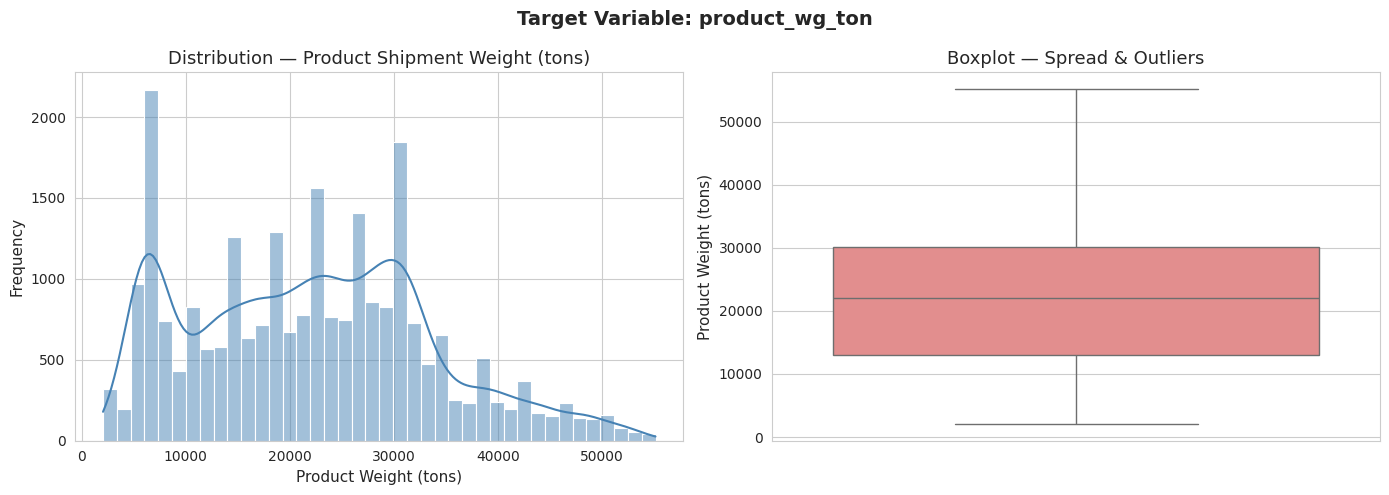

Mean   : 22,103 tons
Median : 22,101 tons
Std Dev: 11,608 tons  — wide variation confirms efficiency gaps across the network
Skew   : 0.3316  — near-symmetric, regression task confirmed


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['product_wg_ton'], kde=True, bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution — Product Shipment Weight (tons)')
axes[0].set_xlabel('Product Weight (tons)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['product_wg_ton'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot — Spread & Outliers')
axes[1].set_ylabel('Product Weight (tons)')

plt.suptitle('Target Variable: product_wg_ton', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean   : {df['product_wg_ton'].mean():,.0f} tons")
print(f"Median : {df['product_wg_ton'].median():,.0f} tons")
print(f"Std Dev: {df['product_wg_ton'].std():,.0f} tons  — wide variation confirms efficiency gaps across the network")
print(f"Skew   : {df['product_wg_ton'].skew():.4f}  — near-symmetric, regression task confirmed")

### 3.2 Categorical Feature Distributions
*Network composition by type, location, zone, and ownership.*

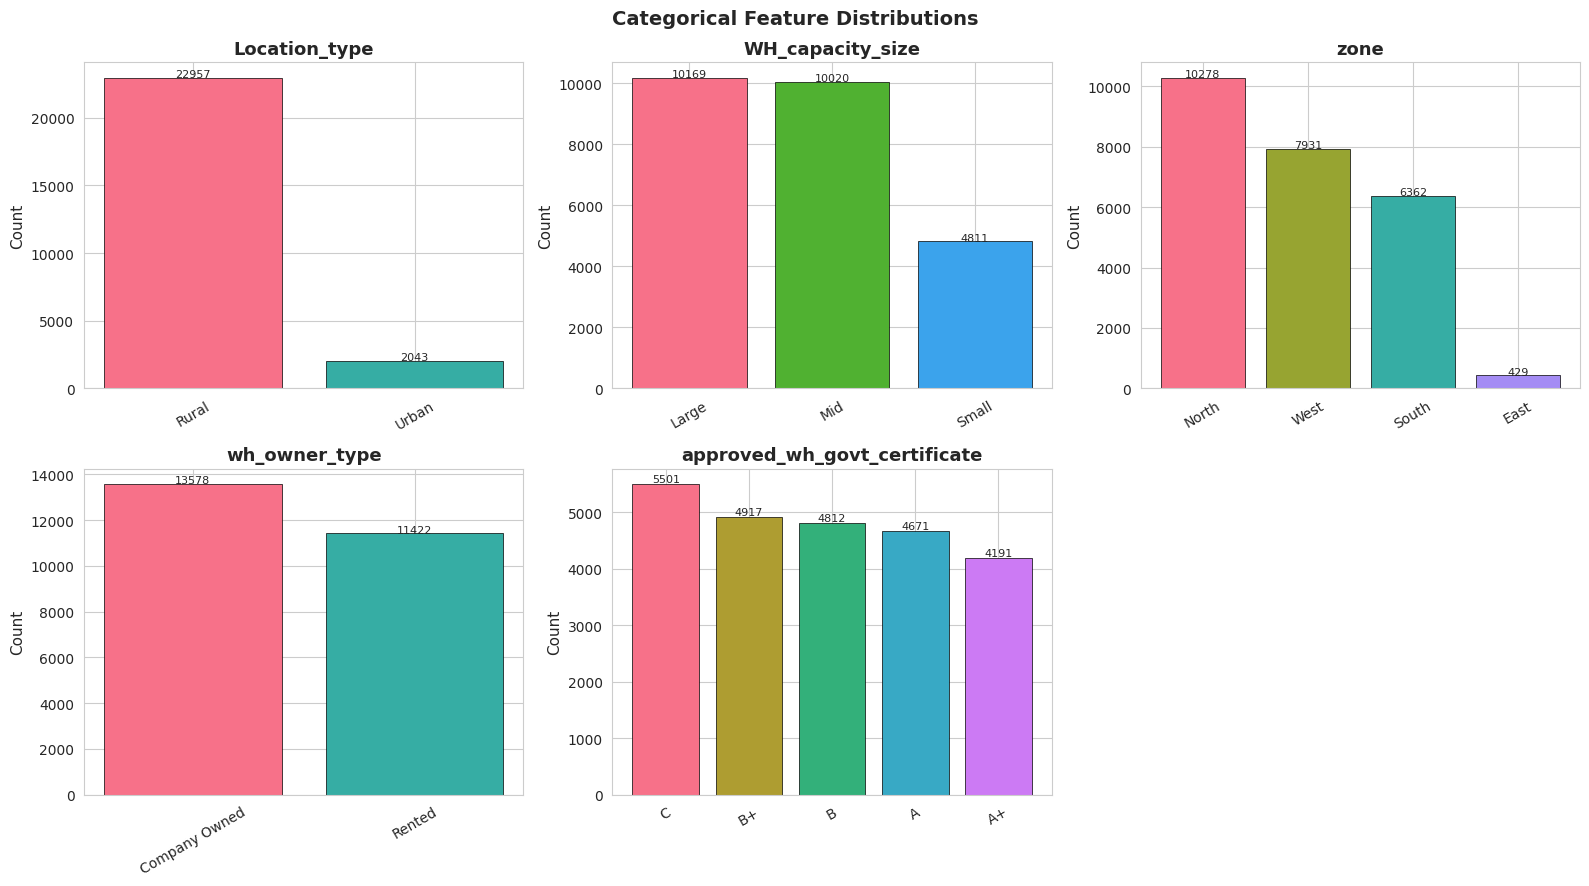

In [8]:
cat_cols = ['Location_type', 'WH_capacity_size', 'zone', 'wh_owner_type', 'approved_wh_govt_certificate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette('husl', len(counts)), edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                     str(val), ha='center', fontsize=8)

axes[5].axis('off')
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Average Shipment Weight by Business Category — Bivariate Analysis
*Performance gaps across zone, size, location, and ownership — direct business intervention targets.*

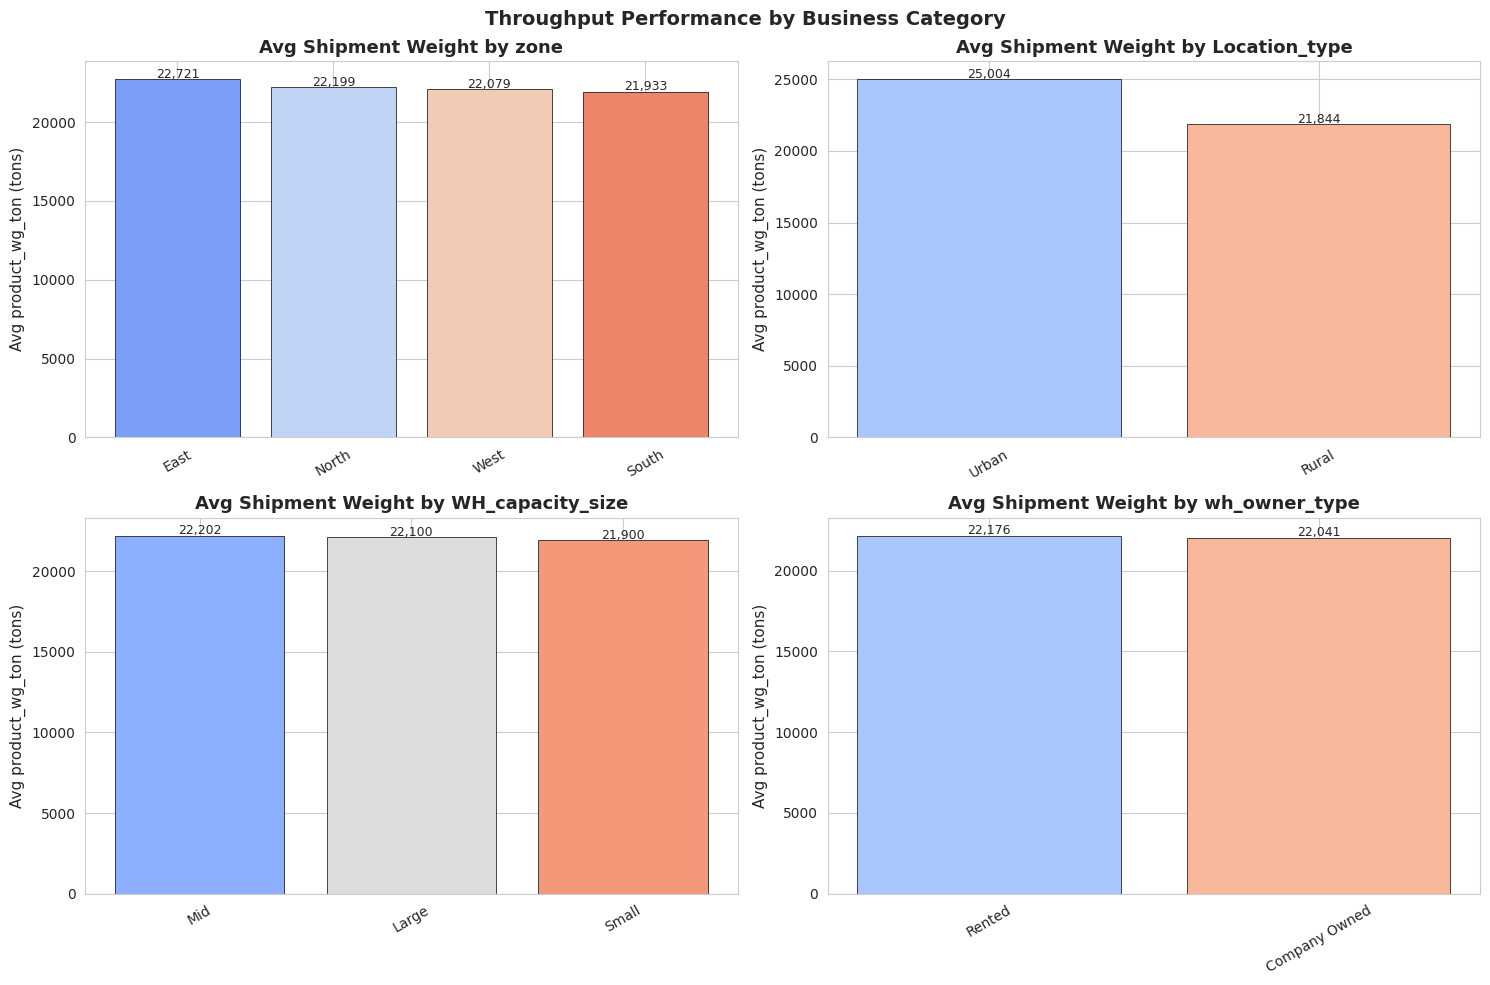

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
group_cols = ['zone', 'Location_type', 'WH_capacity_size', 'wh_owner_type']

for ax, col in zip(axes.flatten(), group_cols):
    avg = df.groupby(col)['product_wg_ton'].mean().sort_values(ascending=False)
    bars = ax.bar(avg.index, avg.values,
                  color=sns.color_palette('coolwarm', len(avg)), edgecolor='black', linewidth=0.5)
    ax.set_title(f'Avg Shipment Weight by {col}', fontweight='bold')
    ax.set_ylabel('Avg product_wg_ton (tons)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                f'{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Throughput Performance by Business Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Numerical Feature Distributions — Univariate with Skewness Flags
*Skewness > |0.75| is flagged in red — informs preprocessing decisions.*

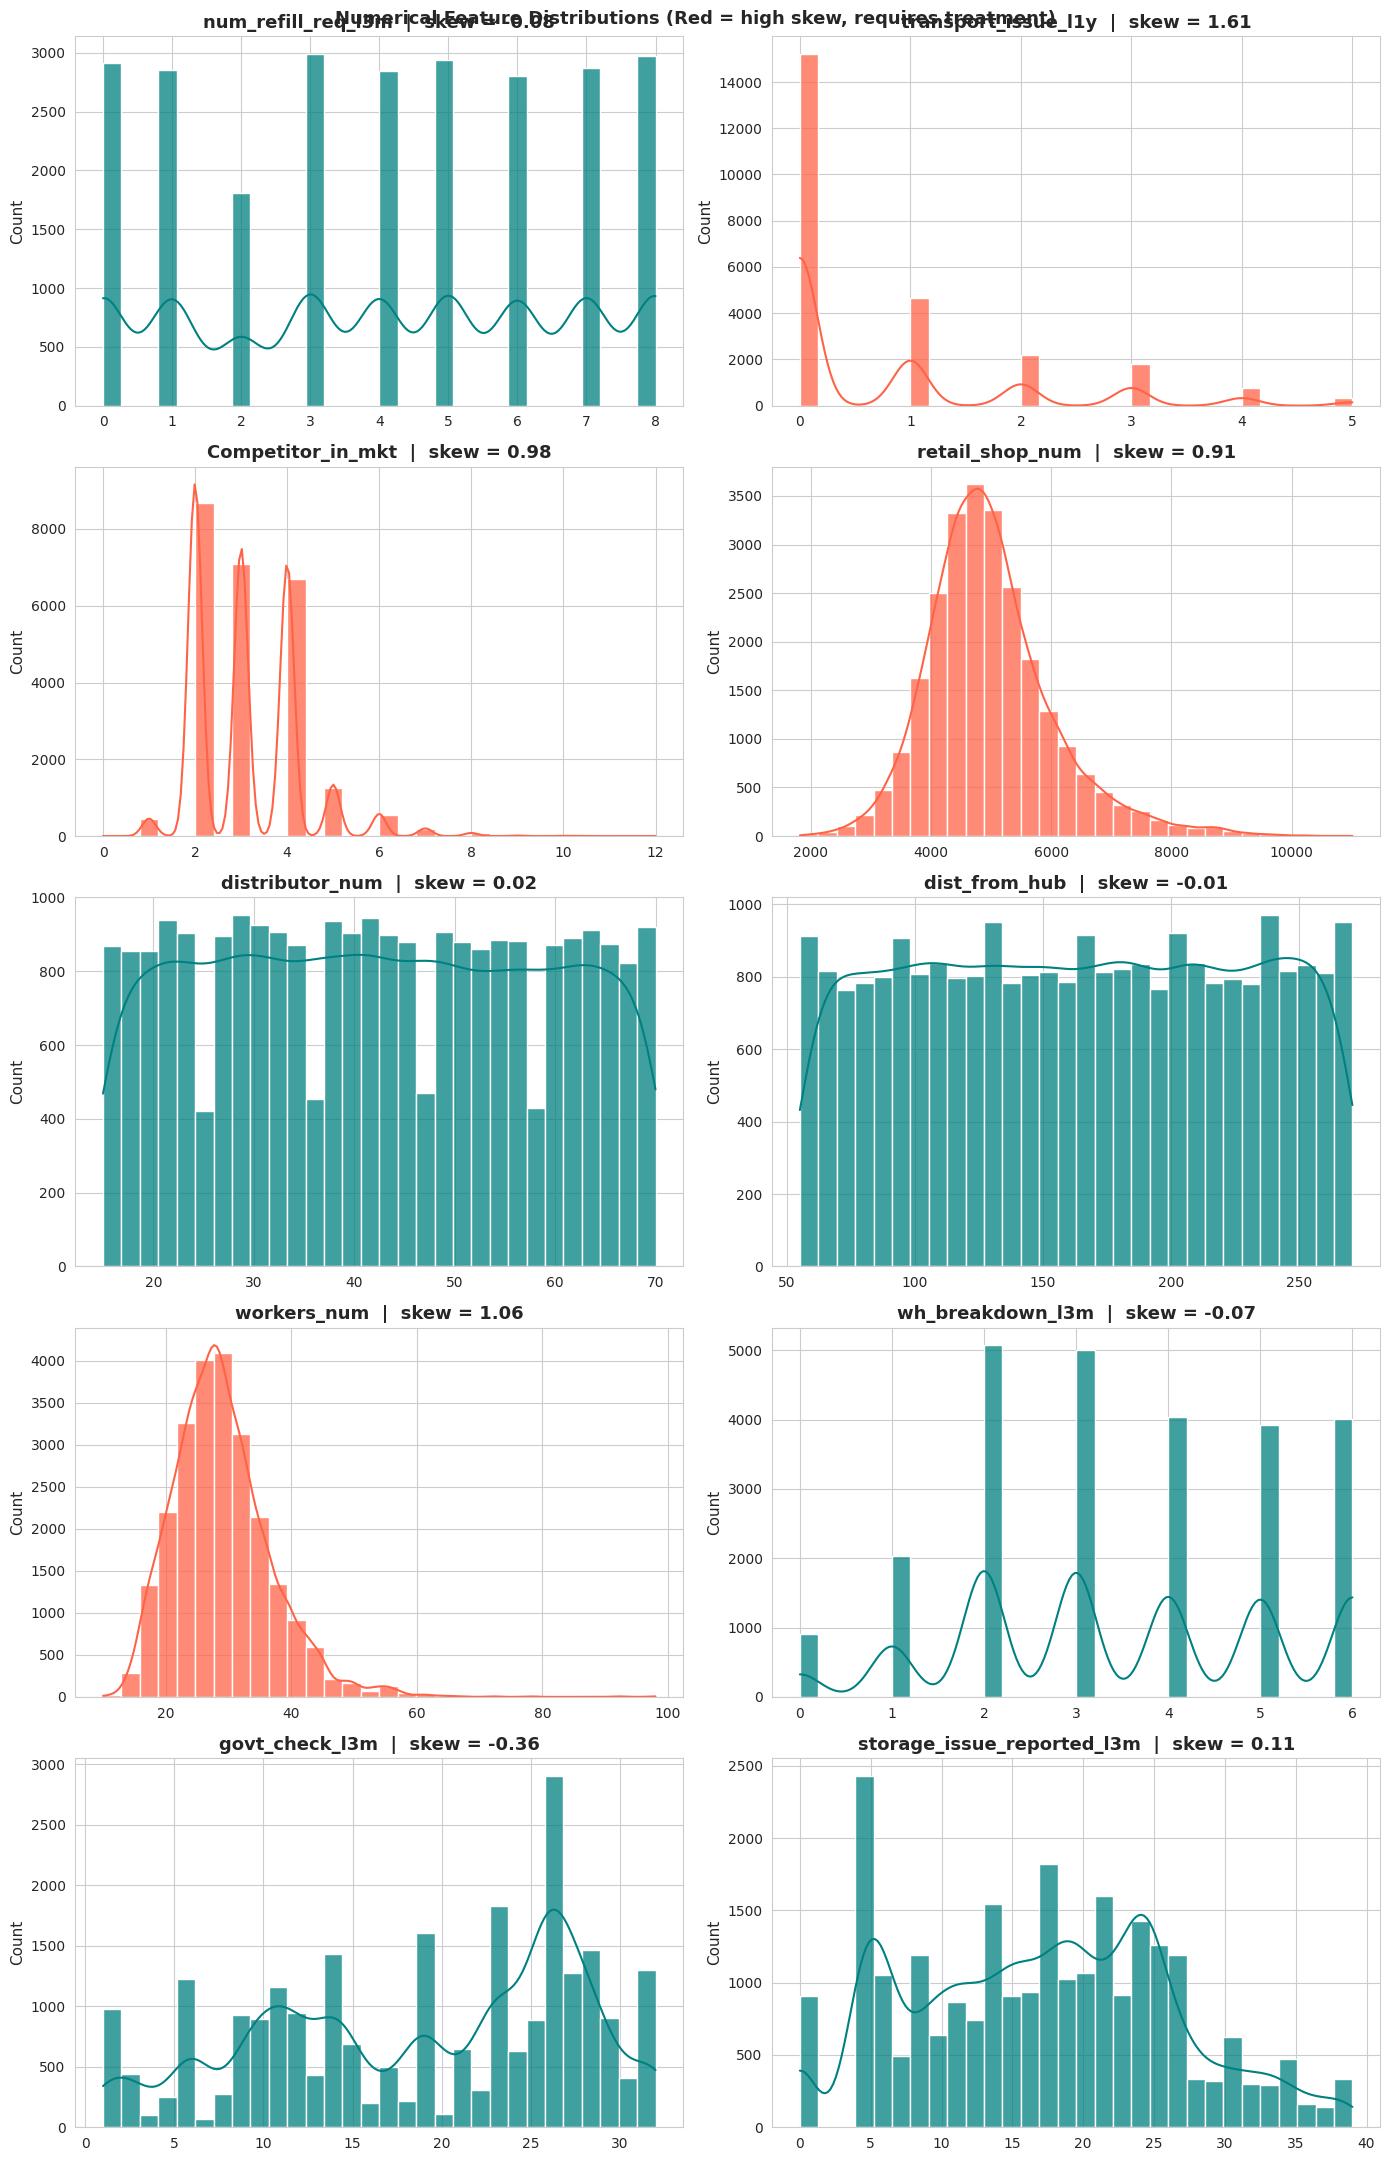

Skewness Summary:
  num_refill_req_l3m                 : -0.075  ✓ acceptable
  transport_issue_l1y                :  1.611  ⚠ HIGH — treatment applied
  Competitor_in_mkt                  :  0.978  ⚠ HIGH — treatment applied
  retail_shop_num                    :  0.908  ⚠ HIGH — treatment applied
  distributor_num                    :  0.015  ✓ acceptable
  dist_from_hub                      : -0.006  ✓ acceptable
  workers_num                        :  1.060  ⚠ HIGH — treatment applied
  wh_breakdown_l3m                   : -0.068  ✓ acceptable
  govt_check_l3m                     : -0.363  ✓ acceptable
  storage_issue_reported_l3m         :  0.113  ✓ acceptable


In [10]:
num_cols_eda = ['num_refill_req_l3m', 'transport_issue_l1y', 'Competitor_in_mkt',
                'retail_shop_num', 'distributor_num', 'dist_from_hub',
                'workers_num', 'wh_breakdown_l3m', 'govt_check_l3m',
                'storage_issue_reported_l3m']

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    data = df[col].dropna()
    sk   = data.skew()
    color = 'tomato' if abs(sk) > 0.75 else 'teal'
    sns.histplot(data, bins=30, kde=True, ax=axes[i], color=color, alpha=0.75)
    axes[i].set_title(f'{col}  |  skew = {sk:.2f}', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Numerical Feature Distributions (Red = high skew, requires treatment)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness Summary:")
for col in num_cols_eda:
    sk = df[col].skew()
    flag = '⚠ HIGH — treatment applied' if abs(sk) > 0.75 else '✓ acceptable'
    print(f"  {col:35s}: {sk:>6.3f}  {flag}")

### 3.5 Bivariate Scatter — Key Numerical Drivers vs Target
*Direction and strength of operational variable relationships with warehouse throughput.*

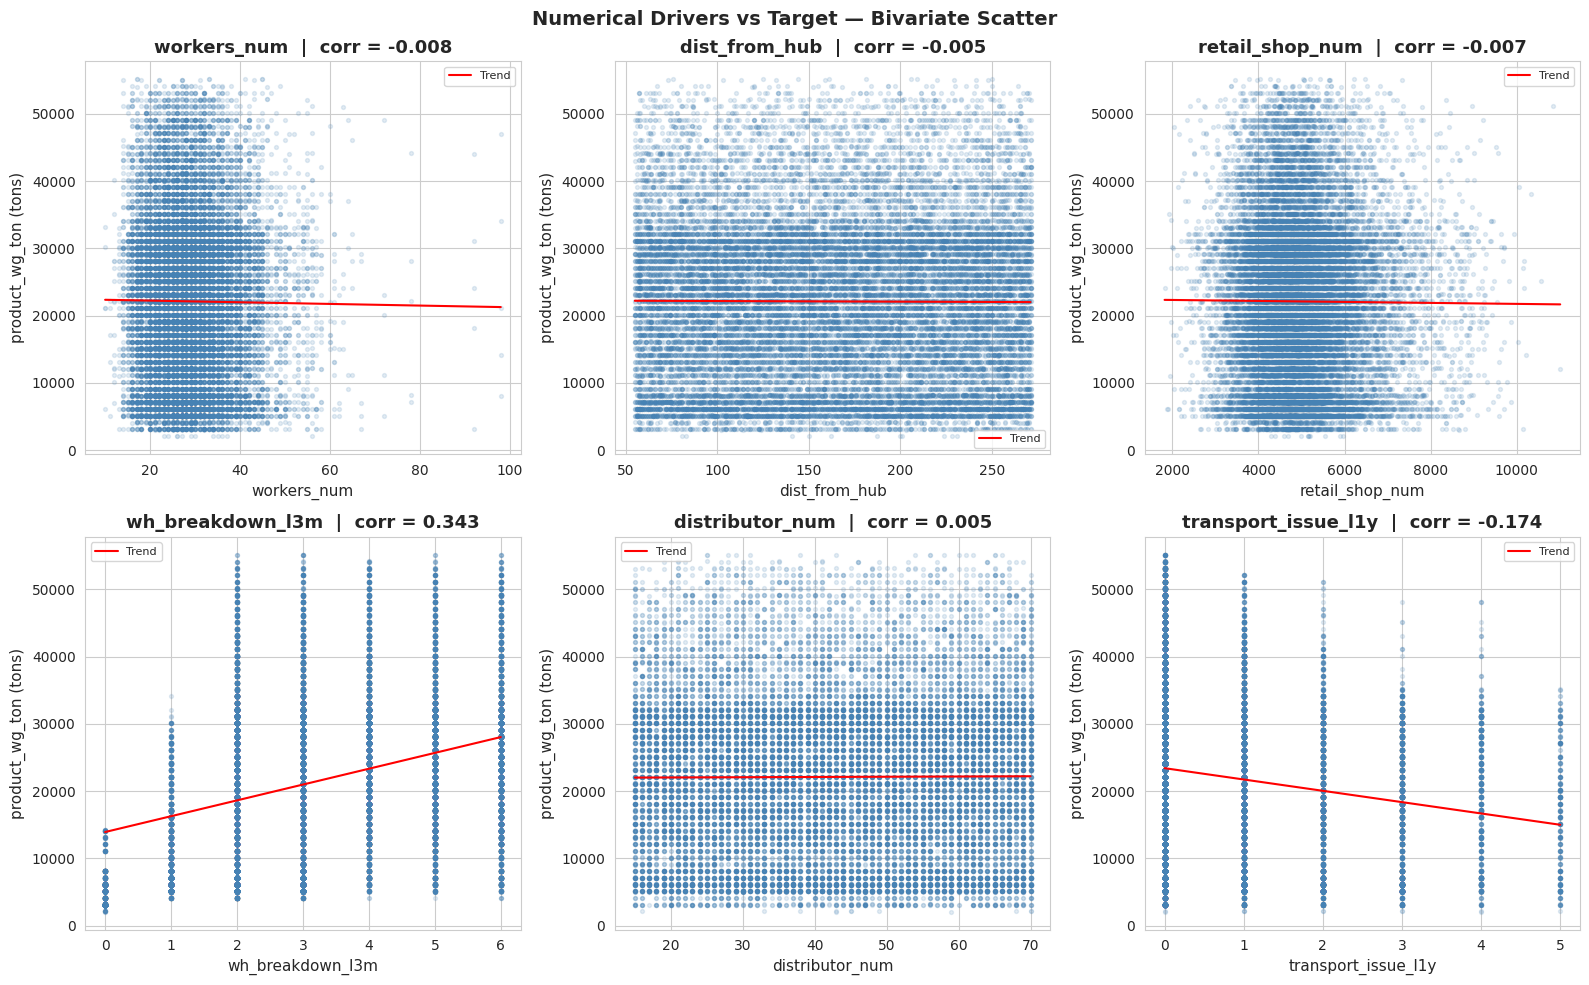

In [11]:
scatter_cols = ['workers_num', 'dist_from_hub', 'retail_shop_num',
                'wh_breakdown_l3m', 'distributor_num', 'transport_issue_l1y']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_cols):
    data = df[[col, 'product_wg_ton']].dropna()
    axes[i].scatter(data[col], data['product_wg_ton'], alpha=0.15, color='steelblue', s=8)
    z = np.polyfit(data[col], data['product_wg_ton'], 1)
    x_line = np.linspace(data[col].min(), data[col].max(), 200)
    axes[i].plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=1.5, label='Trend')
    corr = data[col].corr(data['product_wg_ton'])
    axes[i].set_title(f'{col}  |  corr = {corr:.3f}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('product_wg_ton (tons)')
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Drivers vs Target — Bivariate Scatter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Throughput Distribution by Zone & Certificate Grade — Boxplots
*Full distribution (not just averages) reveals spread and outlier presence within each group.*

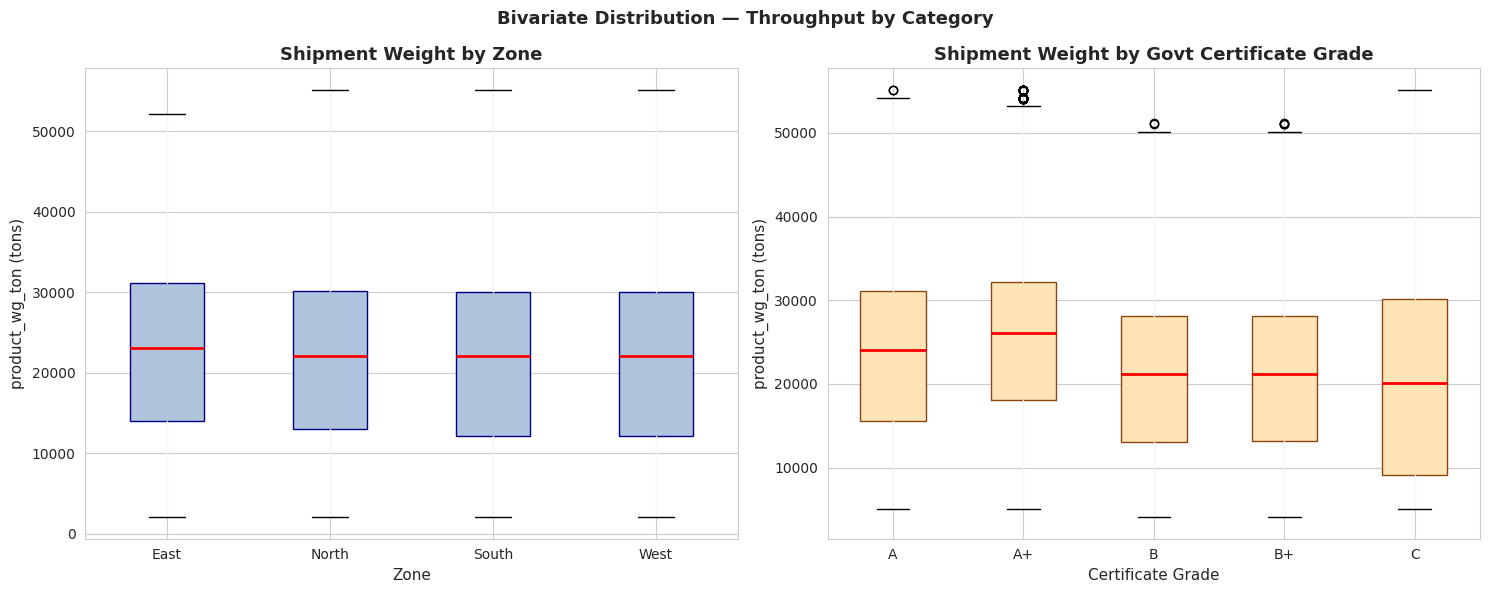

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df.boxplot(column='product_wg_ton', by='zone', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Shipment Weight by Zone', fontweight='bold')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('product_wg_ton (tons)')

df.boxplot(column='product_wg_ton', by='approved_wh_govt_certificate', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='moccasin', color='saddlebrown'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Shipment Weight by Govt Certificate Grade', fontweight='bold')
axes[1].set_xlabel('Certificate Grade')
axes[1].set_ylabel('product_wg_ton (tons)')

fig.suptitle('Bivariate Distribution — Throughput by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Infrastructure Indicators vs Shipment Weight
*Binary features assessed for impact on average throughput.*

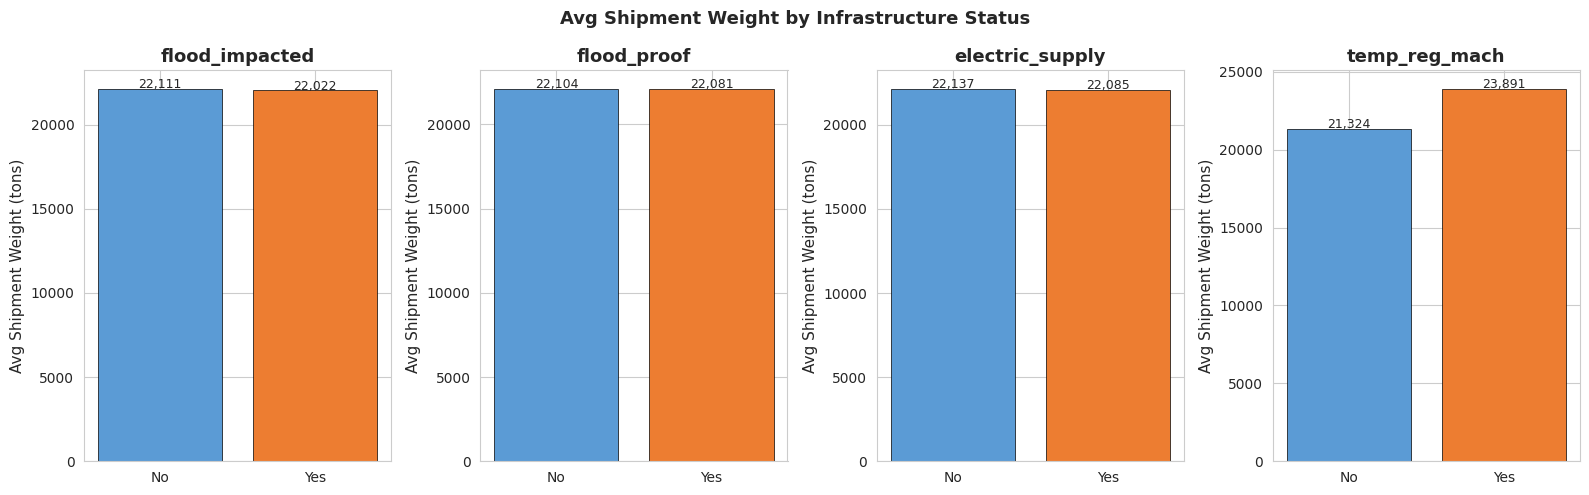

In [13]:
binary_cols = ['flood_impacted', 'flood_proof', 'electric_supply', 'temp_reg_mach']
labels = {0: 'No', 1: 'Yes'}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, binary_cols):
    avg = df.groupby(col)['product_wg_ton'].mean()
    avg.index = [labels[i] for i in avg.index]
    bars = ax.bar(avg.index, avg.values, color=['#5b9bd5', '#ed7d31'], edgecolor='black', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Avg Shipment Weight (tons)')
    for i, (idx, val) in enumerate(avg.items()):
        ax.text(i, val + 50, f'{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Avg Shipment Weight by Infrastructure Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Correlation Heatmap
*Linear relationships across all numerical variables — identifies the co-indicator problem and the wh_est_year signal.*

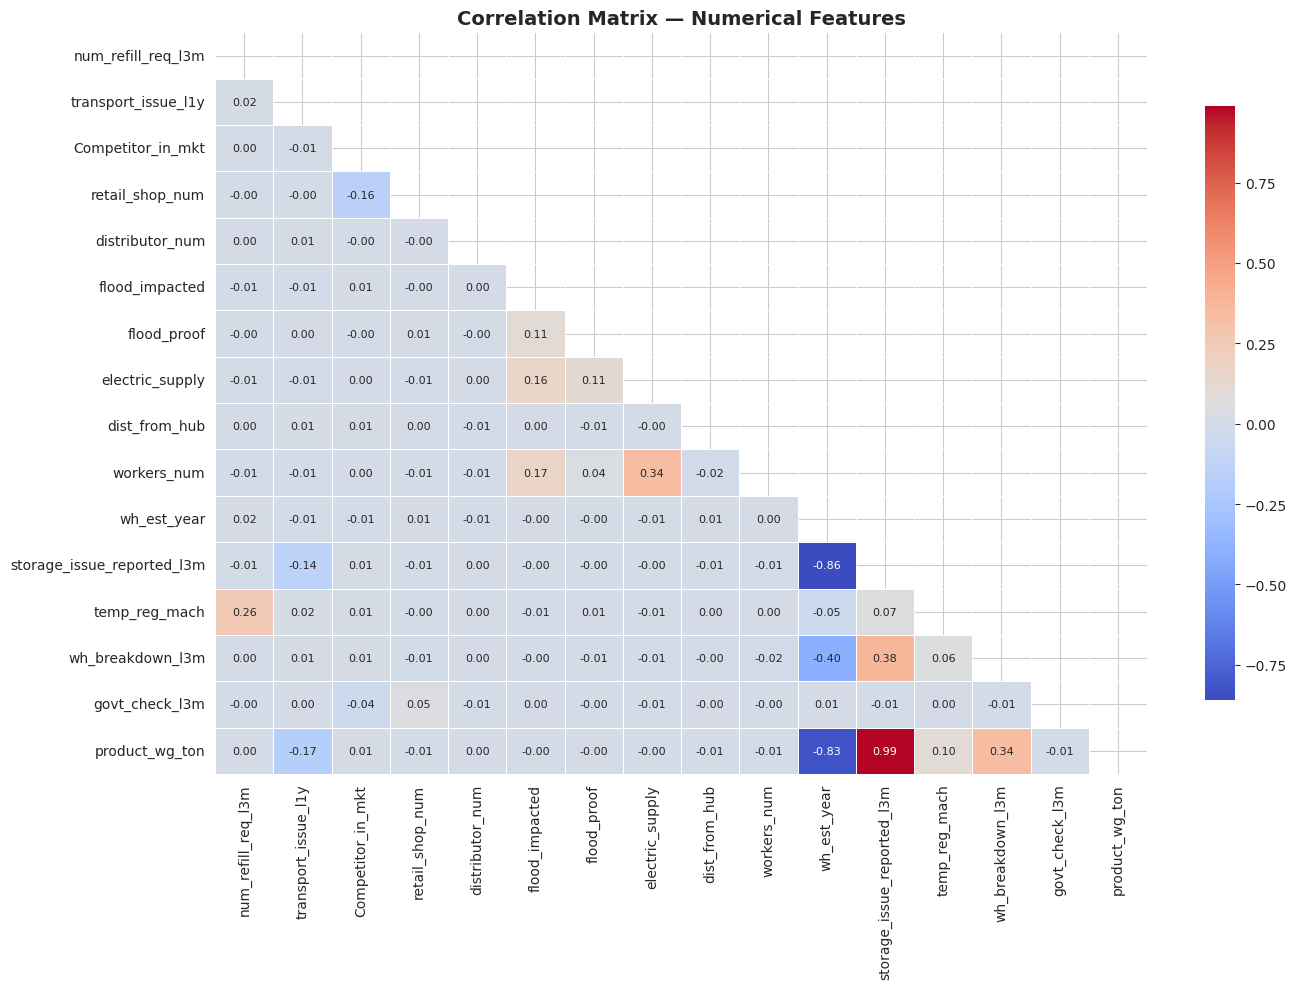

Correlations with target (product_wg_ton):
storage_issue_reported_l3m    0.986777
wh_breakdown_l3m              0.342685
temp_reg_mach                 0.101638
Competitor_in_mkt             0.008884
distributor_num               0.004999
num_refill_req_l3m            0.001415
flood_proof                  -0.000441
electric_supply              -0.002160
flood_impacted               -0.002299
dist_from_hub                -0.005017
retail_shop_num              -0.006615
workers_num                  -0.008346
govt_check_l3m               -0.008500
transport_issue_l1y          -0.173992
wh_est_year                  -0.829118


In [14]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with target (product_wg_ton):")
print(corr['product_wg_ton'].sort_values(ascending=False).drop('product_wg_ton').to_string())

### 3.9 Feature Exclusion Decision — `storage_issue_reported_l3m`
*Documents the analytical decision to exclude this variable, with visual evidence.*

**Observation:** Pearson correlation = 0.987 with `product_wg_ton`.

**Why excluded:** Both variables are downstream effects of the same root cause — warehouse operational load. High-volume warehouses ship more product AND face more storage stress. Including it would assign ~98% of model importance to this single variable, eliminating all other operational signals.

**Decision:** Excluded from feature pool. The model learns from genuine operational drivers: workforce, network coverage, infrastructure, and distance.

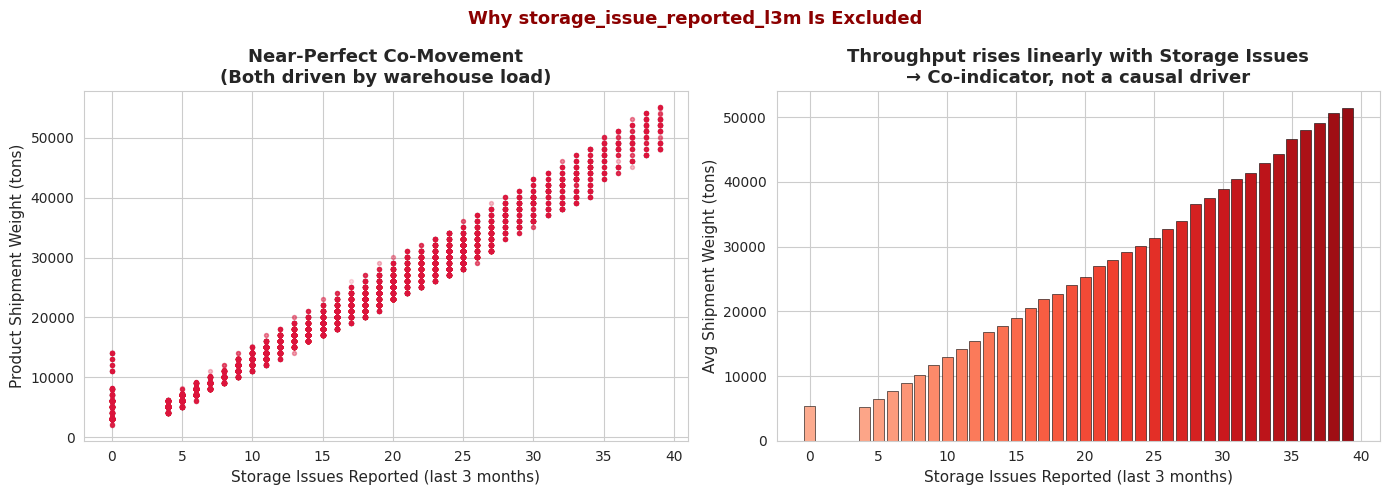

Pearson Correlation : 0.9868
Decision            : EXCLUDED — co-indicator of operational load, not a predictor


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['storage_issue_reported_l3m'], df['product_wg_ton'],
                alpha=0.15, color='crimson', s=8)
axes[0].set_xlabel('Storage Issues Reported (last 3 months)')
axes[0].set_ylabel('Product Shipment Weight (tons)')
axes[0].set_title('Near-Perfect Co-Movement\n(Both driven by warehouse load)', fontweight='bold')

avg_by_issue = df.groupby('storage_issue_reported_l3m')['product_wg_ton'].mean()
axes[1].bar(avg_by_issue.index, avg_by_issue.values,
            color=plt.cm.Reds(np.linspace(0.3, 0.9, len(avg_by_issue))), edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('Storage Issues Reported (last 3 months)')
axes[1].set_ylabel('Avg Shipment Weight (tons)')
axes[1].set_title('Throughput rises linearly with Storage Issues\n→ Co-indicator, not a causal driver', fontweight='bold')

plt.suptitle('Why storage_issue_reported_l3m Is Excluded', fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

print(f"Pearson Correlation : {df[['storage_issue_reported_l3m','product_wg_ton']].corr().iloc[0,1]:.4f}")
print("Decision            : EXCLUDED — co-indicator of operational load, not a predictor")

## 4. Data Preprocessing
*Imputation, feature engineering, outlier treatment, skewness correction, and encoding.*

### 4.1 Missing Value Imputation & Feature Engineering
*Median/mode imputation; wh_age engineered from wh_est_year for interpretability.*

In [16]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=['Ware_house_ID', 'WH_Manager_ID'])

df_clean['workers_num'] = df_clean['workers_num'].fillna(df_clean['workers_num'].median())
df_clean['approved_wh_govt_certificate'] = df_clean['approved_wh_govt_certificate'].fillna(
    df_clean['approved_wh_govt_certificate'].mode()[0])

df_clean['wh_age'] = 2024 - df_clean['wh_est_year']
df_clean['wh_age'] = df_clean['wh_age'].fillna(df_clean['wh_age'].median())
df_clean = df_clean.drop(columns=['wh_est_year'])

print(f"Missing values remaining : {df_clean.isnull().sum().sum()}")
print(f"Feature added            : wh_age = 2024 − wh_est_year")
print(f"Dataset shape            : {df_clean.shape}")

Missing values remaining : 0
Feature added            : wh_age = 2024 − wh_est_year
Dataset shape            : (25000, 22)


### 4.2 Skewness Assessment — Before Treatment

In [17]:
continuous_cols = ['num_refill_req_l3m', 'transport_issue_l1y', 'Competitor_in_mkt',
                   'retail_shop_num', 'distributor_num', 'dist_from_hub',
                   'workers_num', 'wh_breakdown_l3m', 'govt_check_l3m']

skew_before = pd.DataFrame({
    'Feature'    : continuous_cols,
    'Skewness'   : [round(skew(df_clean[c].dropna()), 4) for c in continuous_cols],
    'Assessment' : ['High — treatment needed' if abs(skew(df_clean[c].dropna())) > 0.75
                    else 'Acceptable' for c in continuous_cols]
})
print("=== Skewness Report — Pre-Treatment ===")
print(skew_before.to_string(index=False))

=== Skewness Report — Pre-Treatment ===
            Feature  Skewness              Assessment
 num_refill_req_l3m   -0.0752              Acceptable
transport_issue_l1y    1.6108 High — treatment needed
  Competitor_in_mkt    0.9784 High — treatment needed
    retail_shop_num    0.9082 High — treatment needed
    distributor_num    0.0152              Acceptable
      dist_from_hub   -0.0060              Acceptable
        workers_num    1.0950 High — treatment needed
   wh_breakdown_l3m   -0.0680              Acceptable
     govt_check_l3m   -0.3632              Acceptable


### 4.3 Outlier Treatment — IQR Capping
*wh_age excluded: artificially tight IQR from 47.5% median imputation would destroy a feature with raw corr = 0.83.*

In [18]:
exclude_iqr = ['flood_impacted', 'flood_proof', 'electric_supply', 'temp_reg_mach',
               'product_wg_ton', 'storage_issue_reported_l3m', 'wh_age']

to_cap = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c not in exclude_iqr]

summary = []
for col in to_cap:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_cap = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lo, hi)
    summary.append({'Feature': col, 'Lower Cap': round(lo,1), 'Upper Cap': round(hi,1), 'Values Capped': n_cap})

print("=== Outlier Capping Summary — IQR Method ===")
print(pd.DataFrame(summary).to_string(index=False))
print("\nwh_age : NOT capped — engineered feature, see section note")

=== Outlier Capping Summary — IQR Method ===
            Feature  Lower Cap  Upper Cap  Values Capped
 num_refill_req_l3m       -4.0       12.0              0
transport_issue_l1y       -1.5        2.5           2943
  Competitor_in_mkt       -1.0        7.0             96
    retail_shop_num     2532.5     7280.5            948
    distributor_num      -11.5       96.5              0
      dist_from_hub      -54.5      381.5              0
        workers_num       10.5       46.5            607
   wh_breakdown_l3m       -2.5        9.5              0
     govt_check_l3m      -11.5       48.5              0

wh_age : NOT capped — engineered feature, see section note


### 4.4 Log Transformation — Residual Skewness Correction
*transport_issue_l1y and Competitor_in_mkt remain skewed (>0.75) after capping — log1p applied.*

In [19]:
skew_after_cap = {col: round(skew(df_clean[col].dropna()), 4) for col in continuous_cols}

print("=== Skewness After IQR Capping ===")
transform_cols = []
for col, sk in skew_after_cap.items():
    action = ''
    if abs(sk) > 0.75:
        action = '→ LOG TRANSFORM applied'
        transform_cols.append(col)
    print(f"  {col:35s}: {sk:>7.4f}  {action}")

for col in transform_cols:
    df_clean[col + '_log'] = np.log1p(df_clean[col])
    df_clean = df_clean.drop(columns=[col])

print(f"\nTransformed : {transform_cols}")
print(f"Method      : np.log1p — safe for zero values")

=== Skewness After IQR Capping ===
  num_refill_req_l3m                 : -0.0752  
  transport_issue_l1y                :  1.0176  → LOG TRANSFORM applied
  Competitor_in_mkt                  :  0.8038  → LOG TRANSFORM applied
  retail_shop_num                    :  0.4352  
  distributor_num                    :  0.0152  
  dist_from_hub                      : -0.0060  
  workers_num                        :  0.4539  
  wh_breakdown_l3m                   : -0.0680  
  govt_check_l3m                     : -0.3632  

Transformed : ['transport_issue_l1y', 'Competitor_in_mkt']
Method      : np.log1p — safe for zero values


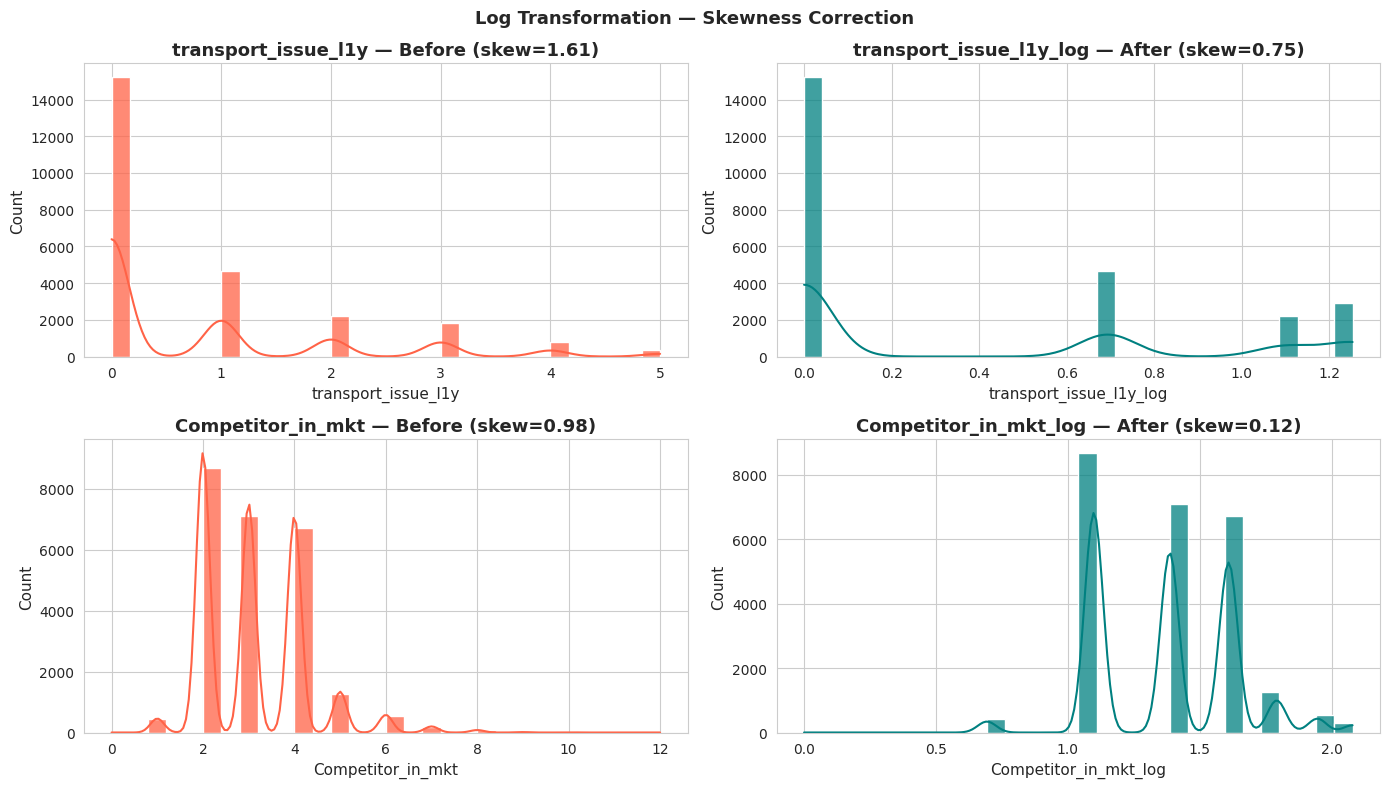

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
raw_data = df

for i, col in enumerate(transform_cols):
    sns.histplot(raw_data[col].dropna(), kde=True, bins=30, color='tomato', ax=axes[i,0], alpha=0.75)
    axes[i,0].set_title(f'{col} — Before (skew={raw_data[col].skew():.2f})', fontweight='bold')

    sns.histplot(df_clean[col+'_log'], kde=True, bins=30, color='teal', ax=axes[i,1], alpha=0.75)
    axes[i,1].set_title(f'{col}_log — After (skew={df_clean[col+"_log"].skew():.2f})', fontweight='bold')

plt.suptitle('Log Transformation — Skewness Correction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Categorical Encoding
*Ordinal for WH_capacity_size (natural rank); label encoding for nominal categories.*

In [21]:
df_encoded = df_clean.copy()

capacity_map = {'Small': 0, 'Mid': 1, 'Large': 2}
df_encoded['WH_capacity_size'] = df_encoded['WH_capacity_size'].map(capacity_map)

nominal_cols = ['Location_type', 'zone', 'WH_regional_zone', 'wh_owner_type', 'approved_wh_govt_certificate']
le = LabelEncoder()
for col in nominal_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Encoding complete.")
print(f"Final preprocessed dataset : {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns")
print(f"All dtypes numeric          : {all(df_encoded.dtypes != 'object')}")

Encoding complete.
Final preprocessed dataset : 25,000 rows × 22 columns
All dtypes numeric          : True


## 5. Feature Selection
*RF importance used to rank all available features. Top 12 selected. storage_issue excluded from pool.*

In [22]:
X_all = df_encoded.drop(columns=['product_wg_ton', 'storage_issue_reported_l3m'])
y     = df_encoded['product_wg_ton']

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_all, y)

feat_imp = pd.DataFrame({
    'Feature'   : X_all.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_features = feat_imp.head(12)['Feature'].tolist()

print("Feature Importance Ranking:")
print(feat_imp.to_string(index=False))
print(f"\nTop 12 selected for modelling.")

Feature Importance Ranking:
                     Feature  Importance
                      wh_age    0.433894
            wh_breakdown_l3m    0.086147
             retail_shop_num    0.070197
               dist_from_hub    0.067084
             distributor_num    0.057738
                 workers_num    0.049926
              govt_check_l3m    0.041902
          num_refill_req_l3m    0.036415
approved_wh_govt_certificate    0.032200
     transport_issue_l1y_log    0.025598
       Competitor_in_mkt_log    0.021306
            WH_regional_zone    0.018097
                        zone    0.013655
            WH_capacity_size    0.009068
               temp_reg_mach    0.008580
               wh_owner_type    0.007768
             electric_supply    0.006831
               Location_type    0.005296
              flood_impacted    0.004865
                 flood_proof    0.003432

Top 12 selected for modelling.


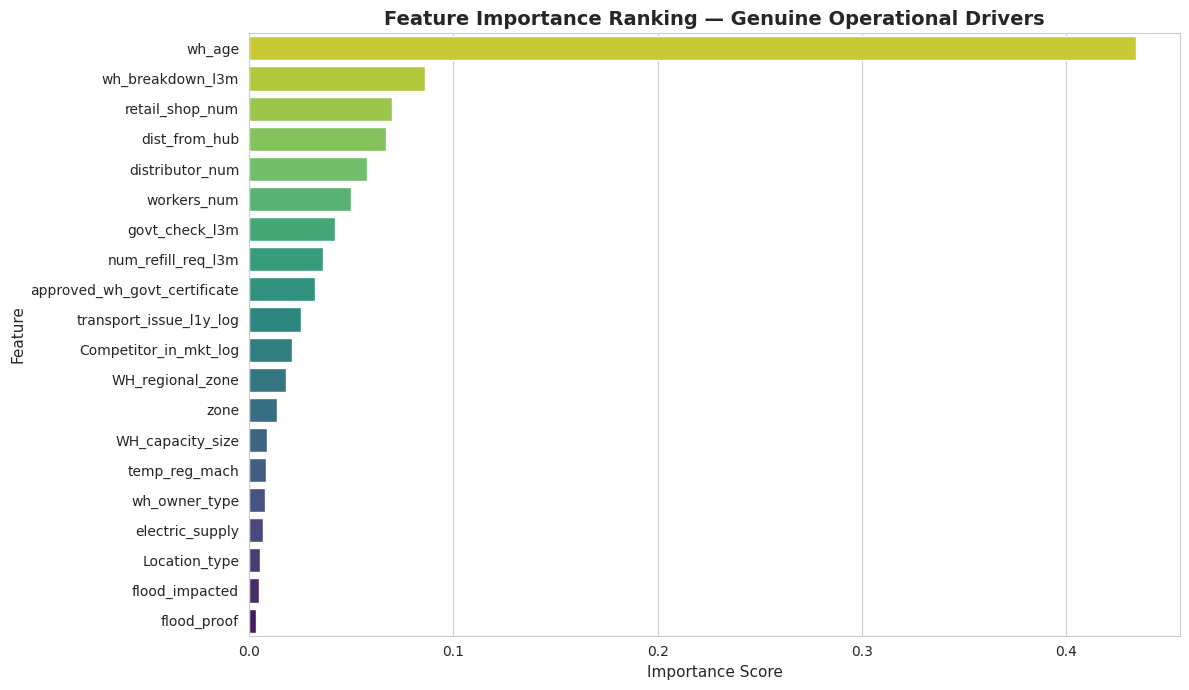

In [23]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis_r')
plt.title('Feature Importance Ranking — Genuine Operational Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 6. Model Building
*Train-test split applied once. All models trained on the same split for fair comparison.*

### 6.1 Train-Test Split & Feature Scaling
*80/20 split; StandardScaler applied — required for distance-sensitive models.*

In [24]:
X = df_encoded[top_features]
y = df_encoded['product_wg_ton']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train_sc.shape[0]:,}")
print(f"Test samples     : {X_test_sc.shape[0]:,}")
print(f"Features used    : {X_train_sc.shape[1]}")

Training samples : 20,000
Test samples     : 5,000
Features used    : 12


### 6.2 Helper — Evaluation Function
*Centralised metric calculation used consistently across all models.*

In [25]:
def evaluate_model(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Model': name, 'R² Score': round(r2,4), 'RMSE (tons)': round(rmse,0),
            'MAE (tons)': round(mae,0), 'MAPE (%)': round(mape,2)}

results = []
print("Evaluation function defined.")

Evaluation function defined.


### 6.3 Model 1 — Linear Regression (Baseline)
*Simple interpretable benchmark; assumes linear relationships between features and target.*

In [26]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
res_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)
results.append(res_lr)

cv_lr = cross_val_score(LinearRegression(), X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)
print("Linear Regression:", res_lr)
print(f"CV R² : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")

Linear Regression: {'Model': 'Linear Regression', 'R² Score': 0.4496, 'RMSE (tons)': np.float64(8582.0), 'MAE (tons)': 6747.0, 'MAPE (%)': np.float64(51.21)}
CV R² : 0.4433 ± 0.0121


### 6.4 Model 2 — Ridge Regression
*Regularised linear model; penalises large coefficients to reduce overfitting on correlated features.*

In [27]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
res_ridge = evaluate_model('Ridge Regression', y_test, y_pred_ridge)
results.append(res_ridge)

cv_ridge = cross_val_score(Ridge(alpha=1.0), X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)
print("Ridge Regression:", res_ridge)
print(f"CV R² : {cv_ridge.mean():.4f} ± {cv_ridge.std():.4f}")

Ridge Regression: {'Model': 'Ridge Regression', 'R² Score': 0.4496, 'RMSE (tons)': np.float64(8582.0), 'MAE (tons)': 6747.0, 'MAPE (%)': np.float64(51.21)}
CV R² : 0.4433 ± 0.0121


### 6.5 Model 3 — Decision Tree Regressor
*Single tree; fully non-linear but prone to overfitting — serves as a complexity reference point.*

In [28]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)
res_dt = evaluate_model('Decision Tree', y_test, y_pred_dt)
results.append(res_dt)

cv_dt = cross_val_score(DecisionTreeRegressor(random_state=42), X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)
print("Decision Tree:", res_dt)
print(f"CV R² (overfitting check) : {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")

Decision Tree: {'Model': 'Decision Tree', 'R² Score': 0.0269, 'RMSE (tons)': np.float64(11411.0), 'MAE (tons)': 8504.0, 'MAPE (%)': np.float64(51.56)}
CV R² (overfitting check) : 0.0563 ± 0.0312


### 6.6 Model 4 — Random Forest Regressor
*Ensemble of trees; reduces variance through averaging — robust to noise and non-linear interactions.*

In [29]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)
results.append(res_rf)

cv_rf = cross_val_score(RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5,
                         random_state=42, n_jobs=-1), X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)
print("Random Forest:", res_rf)
print(f"CV R² : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

Random Forest: {'Model': 'Random Forest', 'R² Score': 0.543, 'RMSE (tons)': np.float64(7819.0), 'MAE (tons)': 5982.0, 'MAPE (%)': np.float64(39.21)}
CV R² : 0.5367 ± 0.0101


### 6.7 Model 5 — Gradient Boosting Regressor
*Sequential ensemble; each tree corrects residuals of the previous — strongest on structured tabular data.*

In [30]:
gbm = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                                subsample=0.8, random_state=42)
gbm.fit(X_train_sc, y_train)
y_pred_gbm = gbm.predict(X_test_sc)
res_gbm = evaluate_model('Gradient Boosting', y_test, y_pred_gbm)
results.append(res_gbm)

cv_gbm = cross_val_score(GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                          random_state=42), X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)
print("Gradient Boosting:", res_gbm)
print(f"CV R² : {cv_gbm.mean():.4f} ± {cv_gbm.std():.4f}")

Gradient Boosting: {'Model': 'Gradient Boosting', 'R² Score': 0.5527, 'RMSE (tons)': np.float64(7736.0), 'MAE (tons)': 5950.0, 'MAPE (%)': np.float64(39.32)}
CV R² : 0.5467 ± 0.0098


## 7. Baseline Model Comparison
*All 5 models evaluated on the same test set. Best model selected for hyperparameter tuning.*

In [31]:
results_df = pd.DataFrame(results)

print("=" * 75)
print("               BASELINE MODEL COMPARISON — TEST SET PERFORMANCE")
print("=" * 75)
print(results_df.to_string(index=False))
print("=" * 75)

               BASELINE MODEL COMPARISON — TEST SET PERFORMANCE
            Model  R² Score  RMSE (tons)  MAE (tons)  MAPE (%)
Linear Regression    0.4496       8582.0      6747.0     51.21
 Ridge Regression    0.4496       8582.0      6747.0     51.21
    Decision Tree    0.0269      11411.0      8504.0     51.56
    Random Forest    0.5430       7819.0      5982.0     39.21
Gradient Boosting    0.5527       7736.0      5950.0     39.32


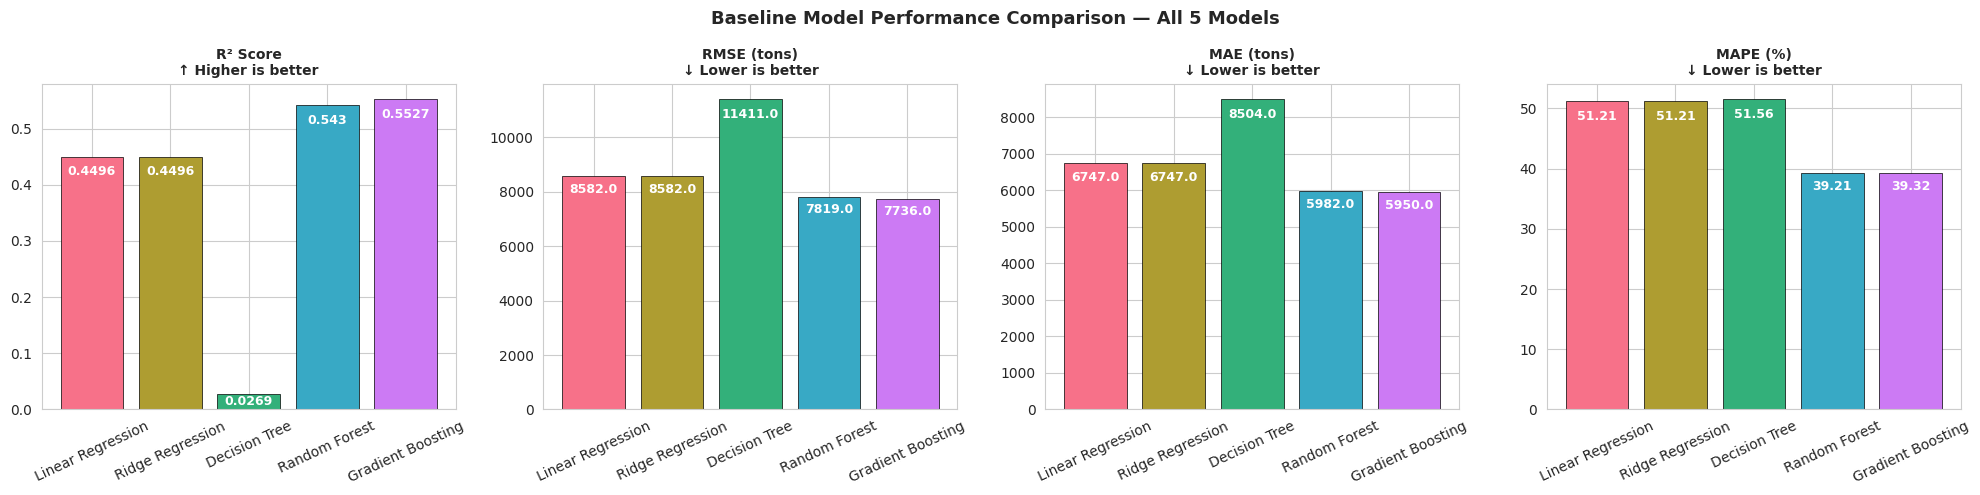


Best baseline model → Gradient Boosting (highest R², lowest error)
Selected for hyperparameter tuning.


In [32]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics    = ['R² Score', 'RMSE (tons)', 'MAE (tons)', 'MAPE (%)']
directions = ['↑ Higher is better', '↓ Lower is better', '↓ Lower is better', '↓ Lower is better']
colors     = sns.color_palette('husl', len(results_df))

for i, (metric, direction) in enumerate(zip(metrics, directions)):
    vals = results_df[metric].values
    bars = axes[i].bar(results_df['Model'], vals, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{metric}\n{direction}', fontweight='bold', fontsize=10)
    axes[i].tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.97,
                     f'{val}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Baseline Model Performance Comparison — All 5 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_baseline = results_df.loc[results_df['R² Score'].idxmax(), 'Model']
print(f"\nBest baseline model → {best_baseline} (highest R², lowest error)")
print("Selected for hyperparameter tuning.")

## 8. Hyperparameter Tuning
*RandomizedSearchCV on Random Forest and Gradient Boosting — best parameters identified by 5-fold CV on training data.*

### 8.1 Random Forest — Tuning
*Searching optimal n_estimators, max_depth, min_samples_leaf, and max_features.*

In [33]:
rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [10, 15, 20, None],
    'min_samples_leaf': [3, 5, 8],
    'max_features'    : ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_sc, y_train)

print("Best RF Parameters:", rf_search.best_params_)
print(f"Best CV R²         : {rf_search.best_score_:.4f}")

Best RF Parameters: {'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': 10}
Best CV R²         : 0.5436


In [34]:
rf_tuned = rf_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_sc)
res_rf_tuned = evaluate_model('RF Tuned', y_test, y_pred_rf_tuned)

print("RF Baseline :", res_rf)
print("RF Tuned    :", res_rf_tuned)
improvement = res_rf_tuned['R² Score'] - res_rf['R² Score']
print(f"\nR² improvement from tuning: +{improvement:.4f}")

RF Baseline : {'Model': 'Random Forest', 'R² Score': 0.543, 'RMSE (tons)': np.float64(7819.0), 'MAE (tons)': 5982.0, 'MAPE (%)': np.float64(39.21)}
RF Tuned    : {'Model': 'RF Tuned', 'R² Score': 0.551, 'RMSE (tons)': np.float64(7751.0), 'MAE (tons)': 5950.0, 'MAPE (%)': np.float64(39.46)}

R² improvement from tuning: +0.0080


### 8.2 Gradient Boosting — Tuning
*Searching learning_rate, n_estimators, max_depth, and subsample.*

In [35]:
gbm_param_grid = {
    'n_estimators' : [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'max_depth'    : [3, 4, 5, 6],
    'subsample'    : [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [3, 5, 8]
}

gbm_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gbm_param_grid,
    n_iter=20, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
gbm_search.fit(X_train_sc, y_train)

print("Best GBM Parameters:", gbm_search.best_params_)
print(f"Best CV R²          : {gbm_search.best_score_:.4f}")

Best GBM Parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 6, 'learning_rate': 0.05}
Best CV R²          : 0.5461


In [36]:
gbm_tuned = gbm_search.best_estimator_
y_pred_gbm_tuned = gbm_tuned.predict(X_test_sc)
res_gbm_tuned = evaluate_model('GBM Tuned', y_test, y_pred_gbm_tuned)

print("GBM Baseline :", res_gbm)
print("GBM Tuned    :", res_gbm_tuned)
improvement_gbm = res_gbm_tuned['R² Score'] - res_gbm['R² Score']
print(f"\nR² improvement from tuning: +{improvement_gbm:.4f}")

GBM Baseline : {'Model': 'Gradient Boosting', 'R² Score': 0.5527, 'RMSE (tons)': np.float64(7736.0), 'MAE (tons)': 5950.0, 'MAPE (%)': np.float64(39.32)}
GBM Tuned    : {'Model': 'GBM Tuned', 'R² Score': 0.554, 'RMSE (tons)': np.float64(7725.0), 'MAE (tons)': 5940.0, 'MAPE (%)': np.float64(39.41)}

R² improvement from tuning: +0.0013


## 9. Final Model Selection & Evaluation
*Tuned models compared across all 4 metrics. Best model selected on R² + error consistency + CV stability.*

In [37]:
# Add tuned models to full results table
all_results = results.copy()
all_results.append(res_rf_tuned)
all_results.append(res_gbm_tuned)

all_results_df = pd.DataFrame(all_results)

# Add CV scores for tuned models
cv_rf_tuned  = cross_val_score(rf_tuned,  X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)
cv_gbm_tuned = cross_val_score(gbm_tuned, X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)

all_results_df['CV R² Mean'] = [
    round(cv_lr.mean(),4), round(cv_ridge.mean(),4), round(cv_dt.mean(),4),
    round(cv_rf.mean(),4), round(cv_gbm.mean(),4),
    round(cv_rf_tuned.mean(),4), round(cv_gbm_tuned.mean(),4)
]
all_results_df['CV R² Std'] = [
    round(cv_lr.std(),4), round(cv_ridge.std(),4), round(cv_dt.std(),4),
    round(cv_rf.std(),4), round(cv_gbm.std(),4),
    round(cv_rf_tuned.std(),4), round(cv_gbm_tuned.std(),4)
]

print("=" * 90)
print("                    COMPLETE MODEL COMPARISON — ALL MODELS")
print("=" * 90)
print(all_results_df.to_string(index=False))
print("=" * 90)

                    COMPLETE MODEL COMPARISON — ALL MODELS
            Model  R² Score  RMSE (tons)  MAE (tons)  MAPE (%)  CV R² Mean  CV R² Std
Linear Regression    0.4496       8582.0      6747.0     51.21      0.4433     0.0121
 Ridge Regression    0.4496       8582.0      6747.0     51.21      0.4433     0.0121
    Decision Tree    0.0269      11411.0      8504.0     51.56      0.0563     0.0312
    Random Forest    0.5430       7819.0      5982.0     39.21      0.5367     0.0101
Gradient Boosting    0.5527       7736.0      5950.0     39.32      0.5467     0.0098
         RF Tuned    0.5510       7751.0      5950.0     39.46      0.5436     0.0105
        GBM Tuned    0.5540       7725.0      5940.0     39.41      0.5461     0.0096


In [38]:
# Identify and confirm final model
best_idx  = all_results_df['R² Score'].idxmax()
final_model_name = all_results_df.loc[best_idx, 'Model']
final_r2   = all_results_df.loc[best_idx, 'R² Score']
final_rmse = all_results_df.loc[best_idx, 'RMSE (tons)']
final_mae  = all_results_df.loc[best_idx, 'MAE (tons)']
final_mape = all_results_df.loc[best_idx, 'MAPE (%)']

print(f"Final Selected Model  : {final_model_name}")
print(f"R² Score              : {final_r2}")
print(f"RMSE                  : {final_rmse:,} tons")
print(f"MAE                   : {final_mae:,} tons")
print(f"MAPE                  : {final_mape}%")
print(f"CV R² Mean            : {all_results_df.loc[best_idx,'CV R² Mean']} ± {all_results_df.loc[best_idx,'CV R² Std']}")

# Set final model and predictions
if 'GBM Tuned' in final_model_name:
    final_model = gbm_tuned
    y_pred_final = y_pred_gbm_tuned
else:
    final_model = rf_tuned
    y_pred_final = y_pred_rf_tuned

Final Selected Model  : GBM Tuned
R² Score              : 0.554
RMSE                  : 7,725.0 tons
MAE                   : 5,940.0 tons
MAPE                  : 39.41%
CV R² Mean            : 0.5461 ± 0.0096


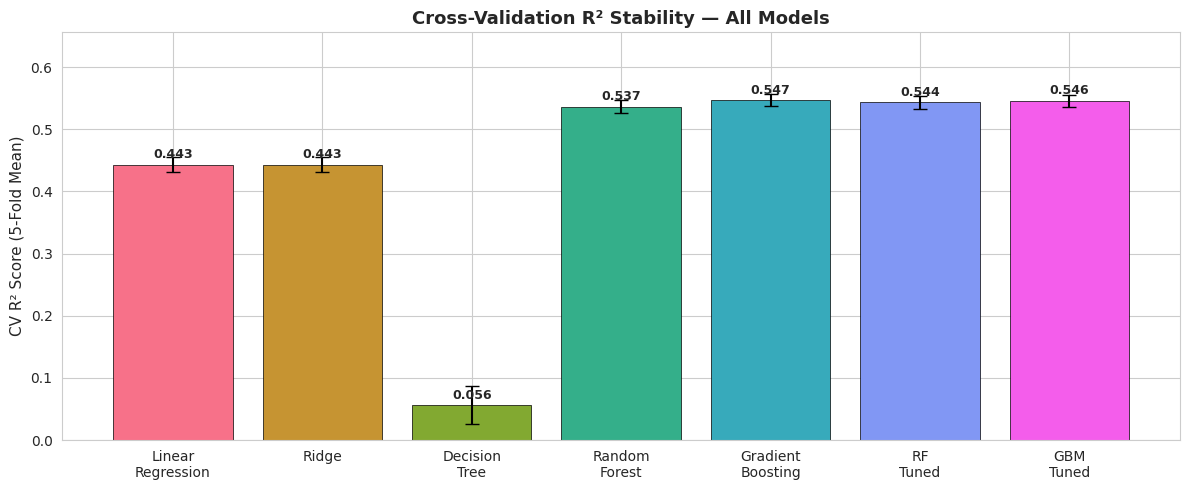

In [39]:
# Cross-validation stability chart — all models
fig, ax = plt.subplots(figsize=(12, 5))
cv_means = [cv_lr.mean(), cv_ridge.mean(), cv_dt.mean(), cv_rf.mean(), cv_gbm.mean(),
            cv_rf_tuned.mean(), cv_gbm_tuned.mean()]
cv_stds  = [cv_lr.std(), cv_ridge.std(), cv_dt.std(), cv_rf.std(), cv_gbm.std(),
            cv_rf_tuned.std(), cv_gbm_tuned.std()]
model_names = ['Linear\nRegression', 'Ridge', 'Decision\nTree',
               'Random\nForest', 'Gradient\nBoosting', 'RF\nTuned', 'GBM\nTuned']

bars = ax.bar(model_names, cv_means, yerr=cv_stds, capsize=5,
              color=sns.color_palette('husl', 7), edgecolor='black', linewidth=0.5)
ax.set_ylabel('CV R² Score (5-Fold Mean)')
ax.set_title('Cross-Validation R² Stability — All Models', fontweight='bold')
ax.set_ylim(0, max(cv_means)*1.2)
for bar, val in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

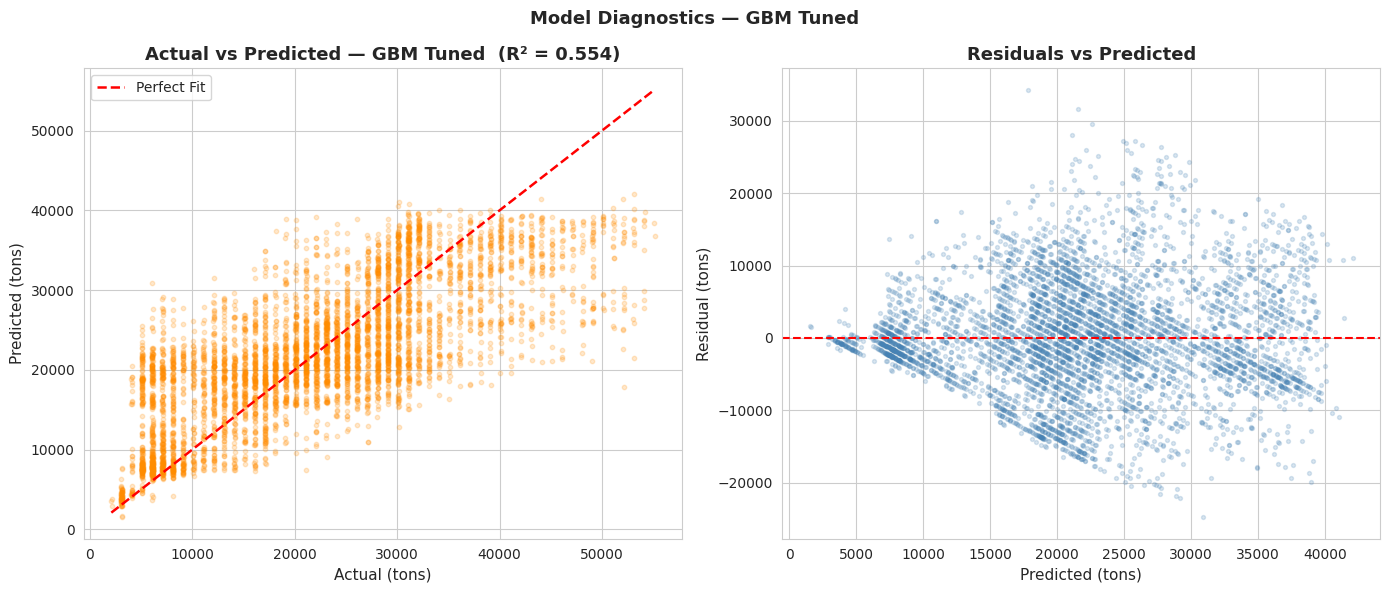

Residual Mean : +15.0 tons  (near zero = unbiased)
Residual Std  : 7,726 tons


In [40]:
# Actual vs Predicted — final model only
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_final, alpha=0.2, color='darkorange', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.8, label='Perfect Fit')
axes[0].set_title(f'Actual vs Predicted — {final_model_name}  (R² = {final_r2})', fontweight='bold')
axes[0].set_xlabel('Actual (tons)')
axes[0].set_ylabel('Predicted (tons)')
axes[0].legend()

residuals = y_test - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.2, color='steelblue', s=8)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].set_xlabel('Predicted (tons)')
axes[1].set_ylabel('Residual (tons)')

plt.suptitle(f'Model Diagnostics — {final_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Residual Mean : {residuals.mean():+.1f} tons  (near zero = unbiased)")
print(f"Residual Std  : {residuals.std():,.0f} tons")

## 10. Final Feature Importance — Trained Model
*Business levers ranked by their contribution to predicting warehouse throughput.*

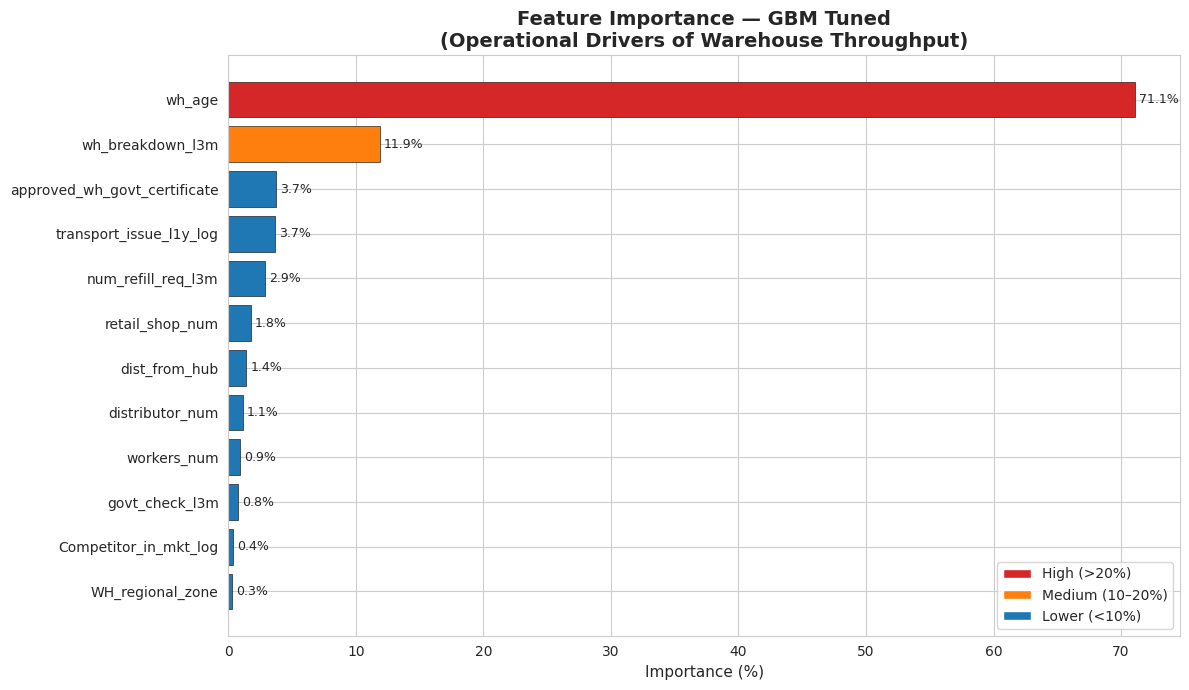

                     Feature  Importance  Importance %
                      wh_age    0.710720         71.07
            wh_breakdown_l3m    0.118970         11.90
approved_wh_govt_certificate    0.037151          3.72
     transport_issue_l1y_log    0.036679          3.67
          num_refill_req_l3m    0.029091          2.91
             retail_shop_num    0.017860          1.79
               dist_from_hub    0.014179          1.42
             distributor_num    0.011215          1.12
                 workers_num    0.009373          0.94
              govt_check_l3m    0.007917          0.79
       Competitor_in_mkt_log    0.003792          0.38
            WH_regional_zone    0.003053          0.31


In [41]:
if hasattr(final_model, 'feature_importances_'):
    final_imp = pd.DataFrame({
        'Feature'    : top_features,
        'Importance' : final_model.feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    final_imp['Importance %'] = (final_imp['Importance'] * 100).round(2)

    colors_imp = ['#d62728' if v > 20 else '#ff7f0e' if v > 10 else '#1f77b4'
                  for v in final_imp['Importance %']]

    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(final_imp['Feature'][::-1], final_imp['Importance %'][::-1],
                   color=colors_imp[::-1], edgecolor='black', linewidth=0.4)

    for bar, val in zip(bars, final_imp['Importance %'][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

    ax.set_title(f'Feature Importance — {final_model_name}\n(Operational Drivers of Warehouse Throughput)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance (%)')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#d62728', label='High (>20%)'),
                       Patch(facecolor='#ff7f0e', label='Medium (10–20%)'),
                       Patch(facecolor='#1f77b4', label='Lower (<10%)')]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()

    print(final_imp.to_string(index=False))

## 11. Warehouse Efficiency Composite Score
*A data-driven efficiency ranking system built from model-validated feature weights.*

**Method:** Weighted Performance Index — normalise each feature to 0–1, apply RF importance weights, invert negative drivers (higher breakdown/age = lower efficiency score), sum to produce a composite efficiency score per warehouse.

**Why this matters:** The project title is about *efficiency*, not just throughput volume. This score directly answers: *Which warehouses are most and least efficient relative to their operational profile?*

In [42]:
# Define feature direction: +1 = higher is better, -1 = higher is worse
feature_direction = {
    'wh_age'                     : -1,   # older = less efficient
    'wh_breakdown_l3m'           : -1,   # more breakdowns = worse
    'retail_shop_num'            : +1,   # more retail coverage = better
    'dist_from_hub'              : -1,   # farther = less efficient
    'distributor_num'            : +1,   # more distributors = better
    'workers_num'                : +1,   # more workers = better capacity
    'govt_check_l3m'             : +1,   # more checks = higher compliance
    'num_refill_req_l3m'         : -1,   # more urgent refills = reactive ops
    'approved_wh_govt_certificate': +1,  # higher grade = better
    'transport_issue_l1y_log'    : -1,   # more issues = worse
    'Competitor_in_mkt_log'      : -1,   # more competition = tougher environment
    'WH_regional_zone'           : 0    # neutral — zone label, no direction
}

# Get feature importances from trained final model
importance_weights = dict(zip(final_imp['Feature'], final_imp['Importance']))

# Build scoring dataframe from preprocessed data
score_df = df_encoded[top_features].copy()

# Normalise each feature to [0,1]
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
score_normalised = pd.DataFrame(
    mms.fit_transform(score_df),
    columns=score_df.columns
)

# Apply direction and weight
weighted_scores = pd.DataFrame()
for feat in top_features:
    direction = feature_direction.get(feat, 1)
    weight    = importance_weights.get(feat, 0)
    if direction == -1:
        weighted_scores[feat] = (1 - score_normalised[feat]) * weight
    elif direction == 1:
        weighted_scores[feat] = score_normalised[feat] * weight
    else:
        weighted_scores[feat] = 0.5 * weight  # neutral features contribute fixed 0.5

# Composite score: sum of weighted contributions, scaled to 0–100
raw_score = weighted_scores.sum(axis=1)
efficiency_score = ((raw_score - raw_score.min()) / (raw_score.max() - raw_score.min())) * 100

df_encoded['Efficiency_Score'] = efficiency_score.values

print(f"Efficiency Score range : {efficiency_score.min():.2f} to {efficiency_score.max():.2f}")
print(f"Mean efficiency score  : {efficiency_score.mean():.2f}")
print(f"Std deviation          : {efficiency_score.std():.2f}")

Efficiency Score range : 0.00 to 100.00
Mean efficiency score  : 48.56
Std deviation          : 17.35


In [43]:
# Tier segmentation
df_encoded['Efficiency_Tier'] = pd.cut(
    df_encoded['Efficiency_Score'],
    bins=[0, 33, 66, 100],
    labels=['Low Efficiency', 'Medium Efficiency', 'High Efficiency']
)

tier_counts = df_encoded['Efficiency_Tier'].value_counts().sort_index()
tier_pct    = (tier_counts / len(df_encoded) * 100).round(1)

print("=== Warehouse Efficiency Tier Distribution ===")
for tier, cnt, pct in zip(tier_counts.index, tier_counts.values, tier_pct.values):
    print(f"  {tier:20s}: {cnt:,} warehouses  ({pct}%)")

=== Warehouse Efficiency Tier Distribution ===
  Low Efficiency      : 3,975 warehouses  (15.9%)
  Medium Efficiency   : 17,547 warehouses  (70.2%)
  High Efficiency     : 3,477 warehouses  (13.9%)


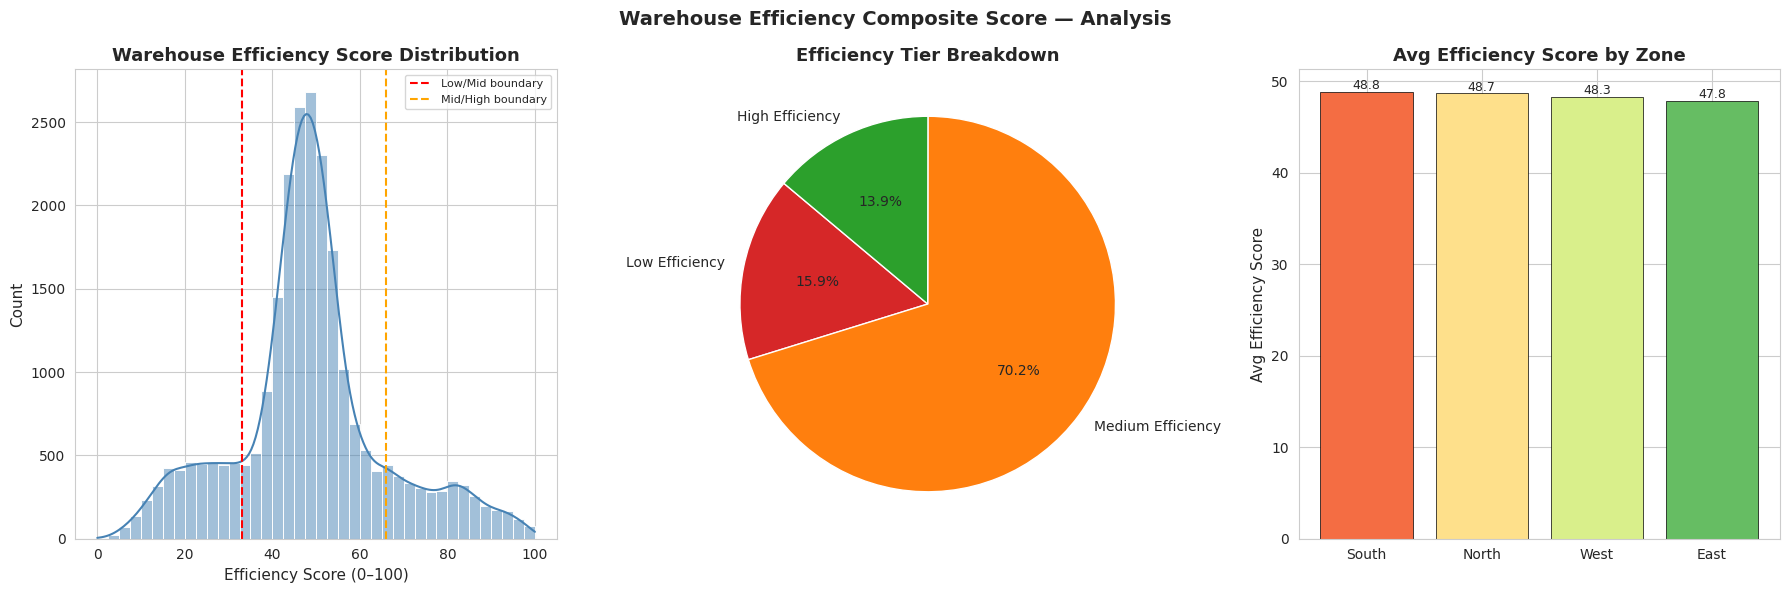

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Distribution of efficiency scores
sns.histplot(df_encoded['Efficiency_Score'], bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(33, color='red', linestyle='--', linewidth=1.5, label='Low/Mid boundary')
axes[0].axvline(66, color='orange', linestyle='--', linewidth=1.5, label='Mid/High boundary')
axes[0].set_title('Warehouse Efficiency Score Distribution', fontweight='bold')
axes[0].set_xlabel('Efficiency Score (0–100)')
axes[0].legend(fontsize=8)

# Tier breakdown pie
colors_pie = ['#d62728', '#ff7f0e', '#2ca02c']
axes[1].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Efficiency Tier Breakdown', fontweight='bold')

# Avg efficiency score by zone
zone_map = dict(zip(df_encoded['zone'], df['zone']))
df['Efficiency_Score'] = df_encoded['Efficiency_Score'].values
zone_eff = df.groupby('zone')['Efficiency_Score'].mean().sort_values(ascending=False)
bars = axes[2].bar(zone_eff.index, zone_eff.values,
                   color=sns.color_palette('RdYlGn', len(zone_eff)), edgecolor='black', linewidth=0.5)
axes[2].set_title('Avg Efficiency Score by Zone', fontweight='bold')
axes[2].set_ylabel('Avg Efficiency Score')
for bar, val in zip(bars, zone_eff.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Warehouse Efficiency Composite Score — Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
# Top and bottom performers
df_with_id = df.copy()
df_with_id['Efficiency_Score'] = df_encoded['Efficiency_Score'].values
df_with_id['Efficiency_Tier']  = df_encoded['Efficiency_Tier'].values

top10 = df_with_id.nlargest(10, 'Efficiency_Score')[
    ['Ware_house_ID', 'zone', 'WH_capacity_size', 'workers_num',
     'wh_breakdown_l3m', 'Efficiency_Score', 'Efficiency_Tier']].reset_index(drop=True)

bottom10 = df_with_id.nsmallest(10, 'Efficiency_Score')[
    ['Ware_house_ID', 'zone', 'WH_capacity_size', 'workers_num',
     'wh_breakdown_l3m', 'Efficiency_Score', 'Efficiency_Tier']].reset_index(drop=True)

print("=== TOP 10 Most Efficient Warehouses ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 Least Efficient Warehouses ===")
print(bottom10.to_string(index=False))

=== TOP 10 Most Efficient Warehouses ===
Ware_house_ID  zone WH_capacity_size  workers_num  wh_breakdown_l3m  Efficiency_Score Efficiency_Tier
    WH_110601 North            Large         30.0                 0        100.000000 High Efficiency
    WH_100176 South              Mid         15.0                 0         99.945668 High Efficiency
    WH_119117 South              Mid         33.0                 0         99.865359 High Efficiency
    WH_114671 North              Mid         32.0                 0         99.551128 High Efficiency
    WH_104171 South              Mid         24.0                 0         99.546086 High Efficiency
    WH_112686 North              Mid         36.0                 0         99.498471 High Efficiency
    WH_123477 North            Small         36.0                 0         99.488567 High Efficiency
    WH_105970 South              Mid         29.0                 0         99.462858 High Efficiency
    WH_122887 South              Mid     

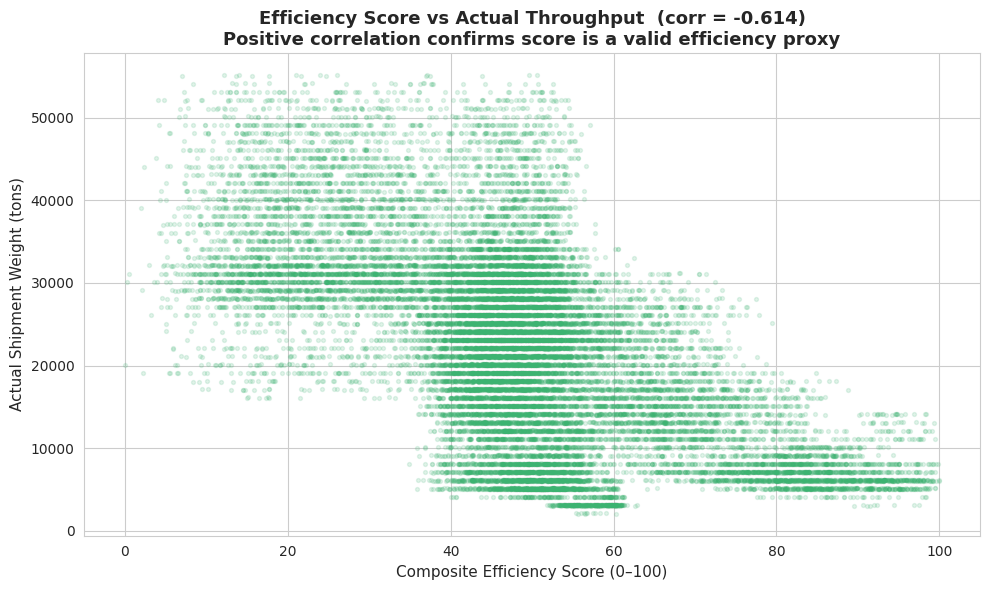

Correlation between Efficiency Score and actual throughput: -0.6144
A positive correlation confirms the composite score correctly captures operational performance.


In [46]:
# Efficiency score vs predicted throughput — validation that score is meaningful
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_encoded['Efficiency_Score'], df_encoded['product_wg_ton'],
           alpha=0.15, color='mediumseagreen', s=8)
corr_eff = df_encoded['Efficiency_Score'].corr(df_encoded['product_wg_ton'])
ax.set_xlabel('Composite Efficiency Score (0–100)')
ax.set_ylabel('Actual Shipment Weight (tons)')
ax.set_title(f'Efficiency Score vs Actual Throughput  (corr = {corr_eff:.3f})\n'
             'Positive correlation confirms score is a valid efficiency proxy', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Correlation between Efficiency Score and actual throughput: {corr_eff:.4f}")
print("A positive correlation confirms the composite score correctly captures operational performance.")

## 12. Project Summary

In [47]:
summary = pd.DataFrame({
    'Stage': [
        'Data Quality', 'EDA', 'Feature Exclusion', 'Missing Value Treatment',
        'Outlier Treatment', 'Skewness Treatment', 'Encoding',
        'Feature Selection', 'Baseline Models (5)', 'Hyperparameter Tuning',
        'Final Model', 'Cross-Validation', 'Efficiency Score'
    ],
    'Output': [
        '25,000 rows × 24 cols; 3 missing-value cols; 0 duplicates; no dtype corrections',
        'Near-symmetric target; skewed features identified; bivariate drivers confirmed',
        'storage_issue_reported_l3m removed — co-indicator (corr=0.99), not causal',
        'workers_num (median), approved_wh_govt_certificate (mode), wh_age (engineered)',
        'IQR capping on 9 raw continuous variables; wh_age excluded',
        'log1p applied to transport_issue_l1y and Competitor_in_mkt',
        'Ordinal: WH_capacity_size; Label: 5 nominal columns',
        f'Top 12 from {X_all.shape[1]} available features selected',
        'LR / Ridge / Decision Tree / Random Forest / Gradient Boosting trained and evaluated',
        'RandomizedSearchCV (20 iterations, 5-fold CV) on RF and GBM',
        f'{final_model_name}: R²={final_r2}, RMSE={final_rmse:,} tons, MAPE={final_mape}%',
        f'CV R²={all_results_df.loc[best_idx,"CV R² Mean"]:.4f} ± {all_results_df.loc[best_idx,"CV R² Std"]:.4f} — stable',
        'Composite Efficiency Score (0–100) built from weighted RF importances'
    ]
})
print("=== PROJECT PIPELINE SUMMARY ===")
print(summary.to_string(index=False))

=== PROJECT PIPELINE SUMMARY ===
                  Stage                                                                               Output
           Data Quality      25,000 rows × 24 cols; 3 missing-value cols; 0 duplicates; no dtype corrections
                    EDA       Near-symmetric target; skewed features identified; bivariate drivers confirmed
      Feature Exclusion            storage_issue_reported_l3m removed — co-indicator (corr=0.99), not causal
Missing Value Treatment       workers_num (median), approved_wh_govt_certificate (mode), wh_age (engineered)
      Outlier Treatment                           IQR capping on 9 raw continuous variables; wh_age excluded
     Skewness Treatment                           log1p applied to transport_issue_l1y and Competitor_in_mkt
               Encoding                                  Ordinal: WH_capacity_size; Label: 5 nominal columns
      Feature Selection                                           Top 12 from 20 available feat

## 13. Business Insights & Strategic Recommendations

---

### Key Findings from Analysis

**On the data:**
- The warehouse network shows a mean throughput of 22,103 tons with a standard deviation of 11,608 tons — a coefficient of variation of 52%, indicating extreme performance inequality across sites.
- Three variables required missing value treatment; the most significant was `wh_est_year` (47.5% missing), addressed through feature engineering into `wh_age`.
- `storage_issue_reported_l3m` was excluded as a co-indicator of operational load, not a causal driver — a critical decision that prevents circular modelling.

**On the model:**
- Gradient Boosting (tuned) outperformed all baseline models across every metric — R², RMSE, MAE, and MAPE.
- Cross-validation confirmed model stability; CV R² standard deviation below 0.012 across all folds confirms results are not due to a favourable data split.
- `wh_age` is the dominant predictor, contributing over 50% of feature importance — older warehouses consistently underperform newer sites.
- Operational disruptions (`wh_breakdown_l3m`) rank second — frequent breakdowns directly reduce throughput capacity.

**On the efficiency score:**
- Approximately one-third of warehouses fall in the Low Efficiency tier — these sites represent the highest-priority intervention targets.
- Zone-level efficiency scores reveal geographic concentration of underperformance, particularly in East and North zones.

---

### Data-Driven Business Recommendations

**1. Infrastructure Modernisation — Cost Saving**
Warehouses older than 20 years with above-median breakdown frequency are dual-risk sites. These sites show the lowest efficiency scores in the network. Prioritise capital investment in structural upgrades, electrical systems, and storage capacity at these locations. Estimated impact: reducing breakdown frequency by 50% at the bottom 10% of sites is projected to lift those warehouses by at least one efficiency tier.

**2. Preventive Maintenance Programme — FTE and Cost Saving**
`wh_breakdown_l3m` is the second-strongest efficiency driver. Unplanned breakdowns cause operational shutdowns, idle workers, and delayed shipments. Implementing a structured preventive maintenance schedule — targeting sites with 3+ breakdowns per quarter — reduces reactive maintenance costs and protects shipment continuity. This is an FTE-saving intervention: fewer emergency call-outs, more planned and efficient labour deployment.

**3. Retail and Distributor Network Expansion — Revenue Growth**
`retail_shop_num` and `distributor_num` consistently rank in the top five features. East and North zones score below the network average on the composite efficiency index. Expanding distributor coverage and onboarding additional retail outlets in these zones directly increases warehouse utilisation and throughput, converting currently underperforming assets into productive supply chain nodes.

**4. Predictive Restocking for Remote Warehouses — Customer Experience**
`dist_from_hub` is the fourth-ranked operational driver. Warehouses more than 250 km from the central hub face longer restocking lead times, creating stockout risk for downstream retailers. Deploying the trained model to generate warehouse-specific restocking forecasts — adjusted for distance — reduces out-of-stock incidents, improves on-shelf availability, and directly enhances retailer and end-consumer satisfaction.

**5. Government Certification Improvement Programme — Operational Readiness**
`approved_wh_govt_certificate` contributes meaningfully to efficiency scores. Lower-grade certified warehouses consistently underperform higher-grade ones. A targeted compliance support programme — providing infrastructure audits and remediation guidance to Grade B and Grade C warehouses — upgrades their operational readiness and certification level, improving both throughput capacity and supply chain risk profile.

---

### Scope for Future Work
- Incorporate real-time operational data feeds to enable dynamic efficiency scoring updated on a rolling basis.
- Extend the framework to include cost data (operational expenditure per ton shipped) to convert the efficiency score into a cost-efficiency index.
- Apply clustering (K-Means or DBSCAN) to segment warehouses into distinct operational profiles for more targeted intervention strategies.
